**Set environment**

In [2]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("data.table")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**File existence**

In [3]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "*XY_full*"
txt_fglob = file.path(txt_fdiry, txt_fname)

vec = Sys.glob(txt_fglob)
vec = basename(vec)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.tsv 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_cv05fold.rds 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_model.rds 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_model.xgb 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_shap_table.rds 
variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_shap_value.rds 


**Import table**

In [6]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_XY = dat
print(dim(dat))
fun_display_table(dat[1:3, 1:6])

[1] 99981   580


Variant_ID,Delta,AC0014:BATF/FOSL:bZIP,AC0078:CTCF/CTCFL:C2H2_ZF,AC0180:ZSCAN/ZNF:C2H2_ZF,AC0241:NFE2L/JUN:bZIP
chr4:74487586:A:G:C,0.9649841,7.116993,6.693877,1.062241,1.914324
chr9:135685432:G:G:C,0.9454227,7.116993,0.000000,-7.061319,1.914325
chr1:173251490:G:G:C,0.9101272,7.116993,0.000000,0.000000,1.914324


In [8]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_shap_table.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
obj = read_rds(txt_fpath)

### assign and show
dat_xgb_shap = obj
print(dim(obj))
fun_display_table(head(obj))

[1] 57789018        7


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID
1,AC0403:DBP/HLF:bZIP,0.1505788,5.865550,0.8256718,0.0012766,chr4:74487586:A:G:C
2,AC0403:DBP/HLF:bZIP,0.1647743,5.865550,0.8256718,0.0012766,chr9:135685432:G:G:C
3,AC0403:DBP/HLF:bZIP,0.1223084,5.865550,0.8256718,0.0012766,chr1:173251490:G:G:C
4,AC0403:DBP/HLF:bZIP,0.1554775,5.865550,0.8256718,0.0012766,chr1:147523391:G:G:C
5,AC0403:DBP/HLF:bZIP,0.1920806,3.999299,0.7220523,0.0012766,chr18:54580749:A:G:T
6,AC0403:DBP/HLF:bZIP,0.1253641,5.865550,0.8256718,0.0012766,chr7:80949454:A:G:C


In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_XY = dat
print(dim(dat))
fun_display_table(dat[1:3, 1:6])

[1] 99960   585


Variant_ID,Delta,AC0048:NFE2L/JUN:bZIP,AC0116:THRB/ESRRA:Nuclear_receptor,AC0125:NR1I/VDR:Nuclear_receptor,"AC0158:PAX:Homeodomain,Paired_box"
chr4:74487586:A:G:C,0.9649841,1.914324,6.131183,6.83804,0.916502
chr9:135685432:G:G:C,0.9454227,1.914325,0.000000,0.00000,0.000000
chr1:173251490:G:G:C,0.9101272,1.914324,0.000000,0.00000,0.000000


In [4]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_shap_table.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
obj = read_rds(txt_fpath)

### assign and show
dat_xgb_shap = obj
print(dim(obj))
fun_display_table(head(obj))

[1] 58276680        7


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID
1,AC0629:DBP/HLF:bZIP,0.1456467,6.198104,0.8479365,0.0012082,chr4:74487586:A:G:C
2,AC0629:DBP/HLF:bZIP,0.1405376,6.198104,0.8479365,0.0012082,chr9:135685432:G:G:C
3,AC0629:DBP/HLF:bZIP,0.1411790,6.198104,0.8479365,0.0012082,chr1:173251490:G:G:C
4,AC0629:DBP/HLF:bZIP,0.1176771,6.198104,0.8479365,0.0012082,chr1:147523391:G:G:C
5,AC0629:DBP/HLF:bZIP,0.1941387,4.409525,0.7475329,0.0012082,chr18:54580749:A:G:T
6,AC0629:DBP/HLF:bZIP,0.1187949,6.198104,0.8479365,0.0012082,chr7:80949454:A:G:C


**Check**

In [9]:
vec_txt_variant = c("chr4:74487586:A:G:C", "chr9:135685432:G:G:C", "chr1:173251490:G:G:C") 
vec_txt_motif = c(
    "AC0048:NFE2L/JUN:bZIP", 
    "AC0116:THRB/ESRRA:Nuclear_receptor", 
    "AC0125:NR1I/VDR:Nuclear_receptor", 
    "AC0158:PAX:Homeodomain,Paired_box"
)

dat = dat_xgb_shap
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec_txt_variant) %>%
    dplyr::filter(variable   %in% vec_txt_motif) %>%
    dplyr::select(Variant_ID, variable, rfvalue) %>%
    dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant)) %>%
    dplyr::mutate(variable   = factor(variable,   levels=vec_txt_motif)) %>%
    tidyr::spread(variable, rfvalue)

fun_display_table(dat)

Variant_ID


## Arrange table

In [10]:
### get the variant and delta (BlueSTARR)
dat = dat_XY
dat = dat %>% dplyr::select(Variant_ID, Delta)

### assign and show
dat_Y = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99981     2


Variant_ID,Delta
chr4:74487586:A:G:C,0.9649841
chr9:135685432:G:G:C,0.9454227
chr1:173251490:G:G:C,0.9101272


In [11]:
### init
dat = dat_xgb_shap

### rename columns clearly
dat = dat %>% dplyr::rename(
    RowID            = ID,           # row id
    Motif            = variable,     # motif name
    SHAP_Value       = value,        # shap score
    Motif_Delta      = rfvalue,      # raw feature = Δ motif log-odds (unobs - obs)
    Motif_Delta_Scaled = stdfvalue,  # min–max scaled within motif
    Mean_SHAP_for_Motif = mean_value # mean |SHAP|
)

### join delta(BlueSTARR)
dat = dat %>% dplyr::left_join(dat_Y, by = "Variant_ID")

### remove non-events
dat = dat %>% dplyr::filter(Motif_Delta != 0)

### define gain/loss event
dat = dat %>% dplyr::mutate(
    Event_Type = dplyr::case_when(
        Motif_Delta > 0 ~ "Gain",
        Motif_Delta < 0 ~ "Loss"
    )
)

### reorder columns
dat = dat %>% dplyr::select(
    RowID,
    Motif,
    Event_Type,
    SHAP_Value,
    Motif_Delta,
    Motif_Delta_Scaled,
    Mean_SHAP_for_Motif,
    Variant_ID,
    Delta
)

### assign and show
dat_event_shap = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 2446456       9


RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta
1,AC0403:DBP/HLF:bZIP,Gain,0.1505788,5.86555,0.8256718,0.0012766,chr4:74487586:A:G:C,0.9649841
2,AC0403:DBP/HLF:bZIP,Gain,0.1647743,5.86555,0.8256718,0.0012766,chr9:135685432:G:G:C,0.9454227
3,AC0403:DBP/HLF:bZIP,Gain,0.1223084,5.86555,0.8256718,0.0012766,chr1:173251490:G:G:C,0.9101272


In [12]:
dat = dat_xgb_shap
print(summary(dat$value))
print(summary(dat$rfvalue))

      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-3.806e-02 -4.077e-06 -5.130e-07  2.600e-08  0.000e+00  1.921e-01 
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-20.66702   0.00000   0.00000  -0.01271   0.00000  20.66702 


In [13]:
dat = dat_event_shap
print(summary(dat$SHAP_Value))
print(summary(dat$Motif_Delta))
print(summary(dat$Delta))

      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-3.806e-02 -1.612e-06  1.437e-06  1.743e-04  2.405e-05  1.921e-01 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-20.6670  -5.5709  -0.9309  -0.3003   5.0282  20.6670 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02361 0.02656 0.03092 0.03713 0.03918 0.96498 


## Summarise SHAP per motif

- `mean_shap_nz > 0` -> when this motif is gained, it on average pushes Δ up -> activator-like.
- `corr_shap_nz > 0` -> stronger motif gain -> larger positive contribution.
- `frac_nonzero` tells you how often the motif gain even happens.

**Helper function**

In [14]:
fun_cor_safe = function(x, y, min_n = 10) {
    idx = is.finite(x) & is.finite(y)
    x   = x[idx]
    y   = y[idx]
    
    if (length(x) <= min_n){ return(NA_real_) }
    if (sd(x) == 0 || sd(y) == 0){ return(NA_real_) }

    res = cor(x, y, method = "spearman")
    return(res)
}

**Summary SHAP values by motifs**

In [15]:
dat = dat_event_shap
dat = dat %>%
    dplyr::group_by(Motif, Event_Type) %>%
    dplyr::summarise(
        Count           = n(),
        Frac_pos        = mean(SHAP_Value > 0),
        Frac_neg        = mean(SHAP_Value < 0),
        Mean_SHAP_Value = mean(SHAP_Value),
        Mean_SHAP_Abs   = mean(abs(SHAP_Value)),
        Corr_SHAP_Motif = fun_cor_safe(SHAP_Value, Motif_Delta, min_n = 10),
        Corr_SHAP_Delta = fun_cor_safe(SHAP_Value, Delta,       min_n = 10),
        .groups = "drop"
    )

### assign and show
dat_motif_shap_summary = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 1156    9


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta
AC0403:DBP/HLF:bZIP,Gain,1718,0.9778813,0.0221187,0.0398565,0.0398985,-0.2703651,0.6960863
AC0403:DBP/HLF:bZIP,Loss,383,0.0026110,0.9973890,-0.0005409,0.0005469,0.0318408,0.0270826
AC0547:ATF/CREB:bZIP,Gain,2096,0.9990458,0.0009542,0.0108390,0.0108395,0.3827125,0.5910318
AC0547:ATF/CREB:bZIP,Loss,574,0.0139373,0.9860627,-0.0001881,0.0002028,-0.1877851,-0.0295332
AC0014:BATF/FOSL:bZIP,Gain,1582,0.5549937,0.4450063,0.0103926,0.0109819,0.2982700,0.3570869
AC0014:BATF/FOSL:bZIP,Loss,1689,0.0035524,0.9964476,-0.0001352,0.0001367,0.0163611,-0.0136008


**Summarize the numeric columns**

In [16]:
### summary of shap summary
dat = dat_motif_shap_summary

### filter out NAs
dat = dat %>% na.omit

### summarize
dat = dat %>% 
    dplyr::summarize(
        across(
            where(is.numeric), 
            list(Min = min, Mean = mean, Median = median, Max = max),
            .names = "{.col}:{.fn}"
        ) 
    )

### arrange to table
dat = dat %>%
    tidyr::pivot_longer(
        cols = everything(),               
        names_to  = c("Variable", ".value"), 
        names_sep = ":"
    )

### show column summary
fun_display_table(dat)

Variable,Min,Mean,Median,Max
Count,122.0000000,2168.1885099,1868.0000000,1.131000e+04
Frac_pos,0.0000000,0.5748954,0.6833523,1.000000e+00
Frac_neg,0.0000000,0.4251046,0.3166477,1.000000e+00
Mean_SHAP_Value,-0.0015991,0.0002198,0.0000129,3.985650e-02
Mean_SHAP_Abs,0.0000000,0.0002874,0.0000447,3.989850e-02
Corr_SHAP_Motif,-0.9582575,0.0207775,0.0288047,9.416752e-01
Corr_SHAP_Delta,-0.2520121,0.0374751,0.0266146,6.960863e-01


## Choose thresholds (importance + correlation)

In [17]:
### init
dat = dat_motif_shap_summary

### filter out NAs
dat = dat %>% na.omit

### threshold for feature importance
num_threshold_imp  = quantile(dat$Mean_SHAP_Abs, 0.9, na.rm = TRUE)

### threshold for feature correlation
num_threshold_corr = 0.1

### threshold for fraction/proportion
num_threshold_frac = 0.5

print(num_threshold_imp)

         90% 
0.0005336505 


## Define motif class

In [18]:
### Define four classes: Gain/Loss × Activator/Repressor
dat = dat_motif_shap_summary

dat = dat %>%
    na.omit() %>%
    dplyr::mutate(
        Class = dplyr::case_when(
            # ================================================================
            # GAIN–ACTIVATOR
            # Gaining the motif increases activity
            # → SHAP mostly positive
            # → Positive SHAP correlates with higher Delta
            # ================================================================
            Event_Type == "Gain" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value > 0 &
            Frac_pos > num_threshold_frac &
            Corr_SHAP_Delta > num_threshold_corr
            ~ "Gain_Activator",

            # ================================================================
            # GAIN–REPRESSOR
            # Gaining the motif decreases activity
            # → SHAP mostly negative
            # → Negative SHAP correlates with lower Delta
            # ================================================================
            Event_Type == "Gain" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value < 0 &
            Frac_neg > num_threshold_frac &
            Corr_SHAP_Delta < -num_threshold_corr
            ~ "Gain_Repressor",

            # ================================================================
            # LOSS–ACTIVATOR
            # Losing the motif decreases activity
            # → SHAP mostly negative
            # → Negative SHAP correlates with lower Delta
            # ================================================================
            Event_Type == "Loss" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value < 0 &
            Frac_neg > num_threshold_frac &
            Corr_SHAP_Delta < -num_threshold_corr
            ~ "Loss_Activator",

            # ================================================================
            # LOSS–REPRESSOR
            # Losing the motif increases activity
            # → SHAP mostly positive
            # → Positive SHAP correlates with higher Delta
            # ================================================================
            Event_Type == "Loss" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value > 0 &
            Frac_pos > num_threshold_frac &
            Corr_SHAP_Delta > num_threshold_corr
            ~ "Loss_Repressor",

            # All others: weak or ambiguous signals
            TRUE ~ "Weak_or_Mixed"
        )
    )

### assign and show
dat_motif_shap_class = dat
print(dim(dat))
print(table(dat$Class))
fun_display_table(head(dat))

[1] 1114   10

Gain_Activator Loss_Repressor  Weak_or_Mixed 
            34             21           1059 


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
AC0403:DBP/HLF:bZIP,Gain,1718,0.9778813,0.0221187,0.0398565,0.0398985,-0.2703651,0.6960863,Gain_Activator
AC0403:DBP/HLF:bZIP,Loss,383,0.0026110,0.9973890,-0.0005409,0.0005469,0.0318408,0.0270826,Weak_or_Mixed
AC0547:ATF/CREB:bZIP,Gain,2096,0.9990458,0.0009542,0.0108390,0.0108395,0.3827125,0.5910318,Gain_Activator
AC0547:ATF/CREB:bZIP,Loss,574,0.0139373,0.9860627,-0.0001881,0.0002028,-0.1877851,-0.0295332,Weak_or_Mixed
AC0014:BATF/FOSL:bZIP,Gain,1582,0.5549937,0.4450063,0.0103926,0.0109819,0.2982700,0.3570869,Gain_Activator
AC0014:BATF/FOSL:bZIP,Loss,1689,0.0035524,0.9964476,-0.0001352,0.0001367,0.0163611,-0.0136008,Weak_or_Mixed


## Save results

In [20]:
dat = dat_event_shap
head(dat)

RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta
<int>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,AC0403:DBP/HLF:bZIP,Gain,0.1505788,5.865550,0.8256718,0.001276607,chr4:74487586:A:G:C,0.9649841
2,AC0403:DBP/HLF:bZIP,Gain,0.1647743,5.865550,0.8256718,0.001276607,chr9:135685432:G:G:C,0.9454227
3,AC0403:DBP/HLF:bZIP,Gain,0.1223084,5.865550,0.8256718,0.001276607,chr1:173251490:G:G:C,0.9101272
4,AC0403:DBP/HLF:bZIP,Gain,0.1554775,5.865550,0.8256718,0.001276607,chr1:147523391:G:G:C,0.9088001
5,AC0403:DBP/HLF:bZIP,Gain,0.1920806,3.999299,0.7220523,0.001276607,chr18:54580749:A:G:T,0.8622959
6,AC0403:DBP/HLF:bZIP,Gain,0.1253641,5.865550,0.8256718,0.001276607,chr7:80949454:A:G:C,0.8393378


In [21]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "results.xgb.summary.event.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

dat = dat_event_shap
write_tsv(dat, txt_fpath)

In [22]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "results.xgb.summary.motif.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

dat = dat_motif_shap_class
write_tsv(dat, txt_fpath)

In [6]:
### get the variant and delta (BlueSTARR)
dat = dat_XY
tmp = dat %>% dplyr::select(Variant_ID, Delta)

### join delta to the shap table
dat = dat_xgb_shap
dat = dat %>% dplyr::left_join(tmp, by = "Variant_ID")
print(dim(dat))

### filter variant-motif pair with motif feature == zero
dat = dat %>% dplyr::filter(rfvalue != 0)

### assign and show
dat_event_shap_arrange = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 58276680        8
[1] 2254209       8


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID,Delta
1,AC0629:DBP/HLF:bZIP,0.1456467,6.198104,0.8479365,0.0012082,chr4:74487586:A:G:C,0.9649841
2,AC0629:DBP/HLF:bZIP,0.1405376,6.198104,0.8479365,0.0012082,chr9:135685432:G:G:C,0.9454227
3,AC0629:DBP/HLF:bZIP,0.1411790,6.198104,0.8479365,0.0012082,chr1:173251490:G:G:C,0.9101272


In [7]:
dat = dat_xgb_shap
print(summary(dat$value))
print(summary(dat$rfvalue))

      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-4.462e-02 -3.238e-06 -4.880e-07  1.000e-08  0.000e+00  2.519e-01 
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-20.66702   0.00000   0.00000  -0.01218   0.00000  20.66702 


In [8]:
dat = dat_shap_arrange
print(summary(dat$Delta))
print(summary(dat$value))
print(summary(dat$rfvalue))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02361 0.02657 0.03094 0.03716 0.03923 0.96498 
      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-4.462e-02 -9.740e-07  8.440e-07  1.875e-04  1.539e-05  2.519e-01 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-20.6670  -5.3144  -1.0980  -0.3149   4.8086  20.6670 


## Summarise SHAP per motif

- `mean_shap_nz > 0` -> when this motif is gained, it on average pushes Δ up -> activator-like.
- `corr_shap_nz > 0` -> stronger motif gain -> larger positive contribution.
- `frac_nonzero` tells you how often the motif gain even happens.

**Helper function**

In [12]:
fun_cor_safe = function(x, y, min_n = 10) {
    idx = is.finite(x) & is.finite(y)
    x   = x[idx]
    y   = y[idx]
    
    if (length(x) <= min_n){ return(NA_real_) }
    if (sd(x) == 0 || sd(y) == 0){ return(NA_real_) }

    res = cor(x, y, method = "spearman")
    return(res)
}

**Summary SHAP values by motifs**

In [13]:
dat = dat_shap_arrange

dat = dat %>%
    dplyr::mutate(
        Variable = as.character(variable),
        Event    = dplyr::case_when(
            rfvalue > 0 ~ "gain",
            rfvalue < 0 ~ "loss",
            TRUE        ~ "zero"
        )
    ) %>%
    dplyr::filter(Event != "zero") %>%
    dplyr::group_by(Variable, Event) %>%
    dplyr::summarise(
        Count           = n(),
        Frac_pos        = mean(value > 0),
        Frac_neg        = mean(value < 0),
        Mean_shap_val   = mean(value),
        Mean_shap_abs   = mean(abs(value)),
        Corr_shap_motif = fun_cor_safe(value, rfvalue, min_n = 10),
        Corr_shap_delta = fun_cor_safe(value, Delta,   min_n = 10),
        .groups = "drop"
    )

### assign and show
dat_motif_shap_summary = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 1166    9


Variable,Event,Count,Frac_pos,Frac_neg,Mean_shap_val,Mean_shap_abs,Corr_shap_motif,Corr_shap_delta
AC0002:EMX/PAX:Homeodomain,gain,504,0.3333333,0.6666667,0.0000730,0.0000848,0.6457177,0.0320005
AC0002:EMX/PAX:Homeodomain,loss,525,0.9752381,0.0247619,0.0006288,0.0007276,-0.3540454,0.1583393
AC0003:HOXB/BARHL:Homeodomain,gain,354,0.8276836,0.1723164,0.0006872,0.0006879,0.6349109,0.1150627
AC0003:HOXB/BARHL:Homeodomain,loss,256,0.0000000,1.0000000,-0.0000022,0.0000022,-0.0106311,-0.0360492
AC0004:PAX/LHX:Homeodomain,gain,588,0.9676871,0.0323129,0.0000021,0.0000022,0.0297507,-0.0430833
AC0004:PAX/LHX:Homeodomain,loss,426,0.0140845,0.9859155,-0.0005134,0.0005267,0.4254299,0.1197257


**Summarize the numeric columns**

In [14]:
### summary of shap summary
dat = dat_motif_shap_summary

### filter out NAs
dat = dat %>% na.omit

### summarize
dat = dat %>% 
    dplyr::summarize(
        across(
            where(is.numeric), 
            list(Min = min, Mean = mean, Median = median, Max = max),
            .names = "{.col}:{.fn}"
        ) 
    )

### arrange to table
dat = dat %>%
    tidyr::pivot_longer(
        cols = everything(),               
        names_to  = c("Variable", ".value"), 
        names_sep = ":"
    )

### show column summary
fun_display_table(dat)

Variable,Min,Mean,Median,Max
Count,151.0000000,2004.5914468,1.68200e+03,1.197700e+04
Frac_pos,0.0000000,0.5605752,6.77261e-01,1.000000e+00
Frac_neg,0.0000000,0.4394248,3.22739e-01,1.000000e+00
Mean_shap_val,-0.0012762,0.0002277,1.19000e-05,3.569940e-02
Mean_shap_abs,0.0000000,0.0002847,3.36000e-05,3.571720e-02
Corr_shap_motif,-0.9601794,0.0156748,2.94224e-02,9.518274e-01
Corr_shap_delta,-0.2888952,0.0368293,2.32255e-02,6.669344e-01


## Choose thresholds (importance + correlation)

In [43]:
### init
dat = dat_motif_shap_summary

### filter out NAs
dat = dat %>% na.omit

### threshold for feature importance
num_threshold_imp  = quantile(dat$Mean_shap_abs, 0.9, na.rm = TRUE)

### threshold for feature correlation
num_threshold_corr = 0.1

### threshold for fraction/proportion
num_threshold_frac = 0.5

print(num_threshold_imp)

         90% 
0.0005520333 


## Define motif classes

In [24]:
### Define four classes: Gain/Loss × Activator/Repressor
dat = dat_motif_shap_summary

dat = dat %>%
    na.omit() %>%
    dplyr::mutate(
        Class = dplyr::case_when(
            # ================================================================
            # GAIN–ACTIVATOR
            # Gaining the motif increases activity
            # → SHAP mostly positive
            # → Positive SHAP correlates with higher Delta
            # ================================================================
            Event_Type == "Gain" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value > 0 &
            Frac_pos > num_threshold_frac &
            Corr_SHAP_Delta > num_threshold_corr
            ~ "gain_activator",

            # ================================================================
            # GAIN–REPRESSOR
            # Gaining the motif decreases activity
            # → SHAP mostly negative
            # → Negative SHAP correlates with lower Delta
            # ================================================================
            Event_Type == "Gain" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value < 0 &
            Frac_neg > num_threshold_frac &
            Corr_SHAP_Delta < -num_threshold_corr
            ~ "gain_repressor",

            # ================================================================
            # LOSS–ACTIVATOR
            # Losing the motif decreases activity
            # → SHAP mostly negative
            # → Negative SHAP correlates with lower Delta
            # ================================================================
            Event_Type == "Loss" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value < 0 &
            Frac_neg > num_threshold_frac &
            Corr_SHAP_Delta < -num_threshold_corr
            ~ "loss_activator",

            # ================================================================
            # LOSS–REPRESSOR
            # Losing the motif increases activity
            # → SHAP mostly positive
            # → Positive SHAP correlates with higher Delta
            # ================================================================
            Event_Type == "Loss" &
            Mean_SHAP_Abs >= num_threshold_imp &
            Mean_SHAP_Value > 0 &
            Frac_pos > num_threshold_frac &
            Corr_SHAP_Delta > num_threshold_corr
            ~ "loss_repressor",

            # All others: weak or ambiguous signals
            TRUE ~ "weak_or_mixed"
        )
    )

### assign and show
dat_motif_shap_class = dat
print(dim(dat))
print(table(dat$Class))
fun_display_table(head(dat))

[1] 1099   10

gain_activator loss_repressor  weak_or_mixed 
            35             25           1039 


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
AC0629:DBP/HLF:bZIP,Gain,1761,0.9840999,0.0159001,0.0356994,0.0357172,0.0667879,0.6669344,gain_activator
AC0629:DBP/HLF:bZIP,Loss,536,0.0055970,0.9944030,-0.0004989,0.0005094,-0.2176396,-0.1020038,weak_or_mixed
AC0083:SNAI/TCF:bHLH,Gain,878,0.0831435,0.9168565,-0.0002066,0.0002970,0.3808659,0.1392862,weak_or_mixed
AC0083:SNAI/TCF:bHLH,Loss,5085,1.0000000,0.0000000,0.0060579,0.0060579,0.4340272,0.3236939,loss_repressor
AC0631:ATF/CREB:bZIP,Gain,2435,0.9889117,0.0110883,0.0112181,0.0114771,-0.0293993,0.4475002,gain_activator
AC0631:ATF/CREB:bZIP,Loss,585,0.0034188,0.9965812,-0.0002651,0.0003243,-0.1923607,0.0200506,weak_or_mixed


In [32]:
dat_motif_gain_activator  = dat_motif_shap_class %>% dplyr::filter(Class == "gain_activator")
dat_motif_gain_repressor  = dat_motif_shap_class %>% dplyr::filter(Class == "gain_repressor")
dat_motif_loss_activator  = dat_motif_shap_class %>% dplyr::filter(Class == "loss_activator")
dat_motif_loss_repressor  = dat_motif_shap_class %>% dplyr::filter(Class == "loss_repressor")

In [33]:
dat = dat_motif_gain_activator
dat = dat %>% dplyr::arrange(desc(Mean_SHAP_Abs))
vec = dat$Motif

vec_txt_motif_gain = vec
print(dim(dat))
fun_display_table(head(dat, 10))

[1] 35 10


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
AC0629:DBP/HLF:bZIP,Gain,1761,0.9840999,0.0159001,0.0356994,0.0357172,0.0667879,0.6669344,gain_activator
AC0450:ZBTB:C2H2_ZF,Gain,861,0.9396051,0.0603949,0.0154773,0.0154997,0.3521655,0.4053632,gain_activator
AC0273:BATF/FOSL:bZIP,Gain,1582,0.6163085,0.3836915,0.0139458,0.0142624,0.3872359,0.3353853,gain_activator
AC0631:ATF/CREB:bZIP,Gain,2435,0.9889117,0.0110883,0.0112181,0.0114771,-0.0293993,0.4475002,gain_activator
AC0270:FOXN:Forkhead,Gain,686,0.9489796,0.0510204,0.0063045,0.0064092,0.3907839,0.5546345,gain_activator
"AC0624:ONECUT:CUT,Homeodomain",Gain,514,0.7976654,0.2023346,0.0063988,0.0064082,0.8100328,0.3931929,gain_activator
AC0048:NFE2L/JUN:bZIP,Gain,2407,0.9709182,0.0290818,0.0044217,0.0044387,-0.4086899,0.3408989,gain_activator
AC0009:DUXA/DUX:Homeodomain,Gain,866,0.9214781,0.0785219,0.0035248,0.0035571,0.7984763,0.1294307,gain_activator
AC0628:CEBPB/CEBPE:bZIP,Gain,1154,0.8284229,0.1715771,0.0021289,0.0032039,-0.4555006,0.5359310,gain_activator
AC0066:USF/BHLHE:bHLH,Gain,2159,0.9939787,0.0060213,0.0030603,0.0030615,-0.1606215,0.1752462,gain_activator


In [34]:
dat = dat_loss_repressor
dat = dat %>% dplyr::arrange(desc(Mean_SHAP_Abs))
vec = dat$Motif

vec_txt_motif_loss = vec
print(dim(dat))
fun_display_table(head(dat, 10))

[1] 25 10


Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
AC0083:SNAI/TCF:bHLH,Loss,5085,1.0000000,0.0000000,0.0060579,0.0060579,0.4340272,0.3236939,loss_repressor
AC0615:ZNF:C2H2_ZF,Loss,3277,0.8721392,0.1278608,0.0052047,0.0052374,-0.6823856,0.3166053,loss_repressor
AC0241:GFI/GFI1B:C2H2_ZF,Loss,1879,0.9941458,0.0058542,0.0049341,0.0049427,-0.4966470,0.2182072,loss_repressor
AC0066:USF/BHLHE:bHLH,Loss,1543,1.0000000,0.0000000,0.0020586,0.0020586,-0.4178708,0.3031752,loss_repressor
AC0236:ZNF:C2H2_ZF,Loss,4620,0.5952381,0.4047619,0.0019113,0.0019912,-0.8132734,0.2707668,loss_repressor
AC0401:ZNF:C2H2_ZF,Loss,1185,0.7080169,0.2919831,0.0012691,0.0013658,-0.1052374,0.1475710,loss_repressor
AC0613:ZNF:C2H2_ZF,Loss,1580,0.7639241,0.2360759,0.0012518,0.0012789,-0.8778774,0.2671113,loss_repressor
AC0652:TEAD:TEA,Loss,1985,0.7279597,0.2720403,0.0012182,0.0012319,-0.8319042,0.2793093,loss_repressor
AC0127:TCF7L/LEF:Sox,Loss,1043,0.7162033,0.2837967,0.0012005,0.0012177,-0.8608788,0.1674345,loss_repressor
AC0364:ZFP:C2H2_ZF,Loss,1354,0.9822747,0.0177253,0.0012024,0.0012034,-0.2943634,0.3260886,loss_repressor


## Get the events

In [51]:
dat = dat_event_shap
num_threshod_delta = quantile(dat$Delta, 0.9, na.rm = TRUE) 

In [60]:
### Cases for Gain–Activators
dat = dat_event_shap
dat = dat %>%
    dplyr::filter(
        Event_Type == "Gain",
        Motif %in% vec_txt_motif_gain,
        SHAP_Value > 0
    ) %>%
    dplyr::mutate(Rank_Score = abs(SHAP_Value) * abs(Motif_Delta)) %>%
    dplyr::arrange(desc(Rank_Score))

### assign and show
dat_event_gain_act = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 42764    10


RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta,Rank_Score
2,AC0273:BATF/FOSL:bZIP,Gain,0.2519374,7.116993,0.9669289,0.0003829,chr9:135685432:G:G:C,0.9454227,1.793036
4,AC0273:BATF/FOSL:bZIP,Gain,0.2489824,7.116993,0.9669289,0.0003829,chr1:147523391:G:G:C,0.9088001,1.772006
1,AC0273:BATF/FOSL:bZIP,Gain,0.2276636,7.116993,0.9669289,0.0003829,chr4:74487586:A:G:C,0.9649841,1.620280


In [61]:
### Loss–Repressors
dat = dat_event_shap
dat = dat %>%
    dplyr::filter(
        Event_Type == "Loss",
        Motif %in% vec_txt_motif_loss,
        SHAP_Value > 0
    ) %>%
    dplyr::mutate(Rank_Score = abs(SHAP_Value) * abs(Motif_Delta)) %>%
    dplyr::arrange(desc(Rank_Score))

### assign and show
dat_event_loss_rep = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 37577    10


RowID,Motif,Event_Type,SHAP_Value,Motif_Delta,Motif_Delta_Scaled,Mean_SHAP_for_Motif,Variant_ID,Delta,Rank_Score
9,AC0615:ZNF:C2H2_ZF,Loss,0.0893059,-11.18755,0.0311716,0.0003667,chr2:6818290:C:C:G,0.7633680,0.9991145
247,AC0241:GFI/GFI1B:C2H2_ZF,Loss,0.0644908,-13.41296,0.0000001,0.0001897,chr10:129462001:A:A:T,0.2544902,0.8650120
31,AC0615:ZNF:C2H2_ZF,Loss,0.0720145,-11.18755,0.0311716,0.0003667,chr4:25078041:G:G:C,0.5533293,0.8056652


In [62]:
# Gain–activators: top variants by strongest Rank_Score
dat_var_gain = dat_event_gain_act %>%
  dplyr::group_by(Variant_ID) %>%
  dplyr::summarise(Max_Rank = max(Rank_Score), .groups = "drop") %>%
  dplyr::arrange(desc(Max_Rank))

vec_txt_variant_gain_act = head(dat_var_gain$Variant_ID, 50)

# Loss–repressors: top variants by strongest Rank_Score
dat_var_loss = dat_event_loss_rep %>%
  dplyr::group_by(Variant_ID) %>%
  dplyr::summarise(Max_Rank = max(Rank_Score), .groups = "drop") %>%
  dplyr::arrange(desc(Max_Rank))

vec_txt_variant_loss_rep = head(dat_var_loss$Variant_ID, 50)

In [65]:
### filter variants
dat = dat_Y
dat = dat %>% dplyr::arrange(desc(Delta))

### get the variants
vec_txt_variant_sort = dat$Variant_ID

In [66]:
### Heatmap data for Gain–Activators
dat_heat_gain = dat_event_gain_act %>%
  dplyr::filter(Variant_ID %in% vec_txt_variant_gain_act) %>%
  dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels = vec_txt_variant_sort),
    Motif      = factor(Motif,      levels = vec_txt_motif_gain)
  )

### Heatmap data for Gain–Activators
dat_heat_loss = dat_event_loss_rep %>%
  dplyr::filter(Variant_ID %in% vec_txt_variant_loss_rep) %>%
  dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels = vec_txt_variant_sort),
    Motif      = factor(Motif,      levels = vec_txt_motif_gain)
  )

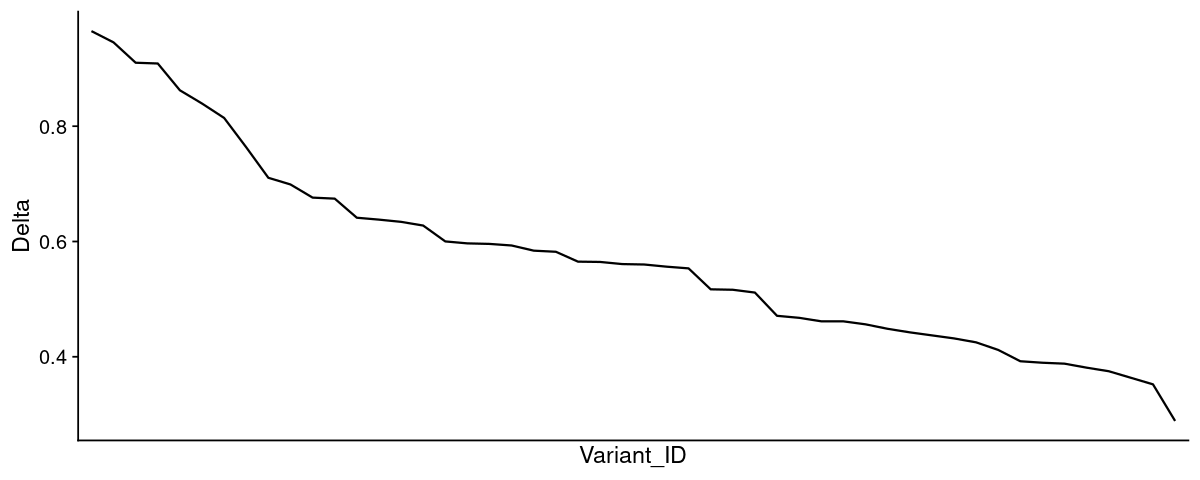

In [67]:
### filter variants
dat = dat_Y
vec = dat_heat_gain$Variant_ID
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec) %>%
    dplyr::arrange(desc(Delta))

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

In [69]:
###
vec_txt_color = RColorBrewer::brewer.pal(9, "Reds")
vec_txt_color = c("#FFFFFF", vec_txt_color)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    #axis.text.y  = element_blank(),
)

###
dat = dat_heat_gain
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    variable   = factor(variable,   levels=rev(vec_txt_motif_gain))
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = Motif, fill = rfvalue)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color, name = "Delta(Motif)") +
    labs(x = "Variant", y = "Motif")

gpt_X = gpt
options(repr.plot.height=7, repr.plot.width=10)
print(gpt)

ERROR: [1m[33mError[39m in `dplyr::mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `variable = factor(variable, levels = rev(vec_txt_motif_gain))`.
[1mCaused by error:[22m
[33m![39m object 'variable' not found


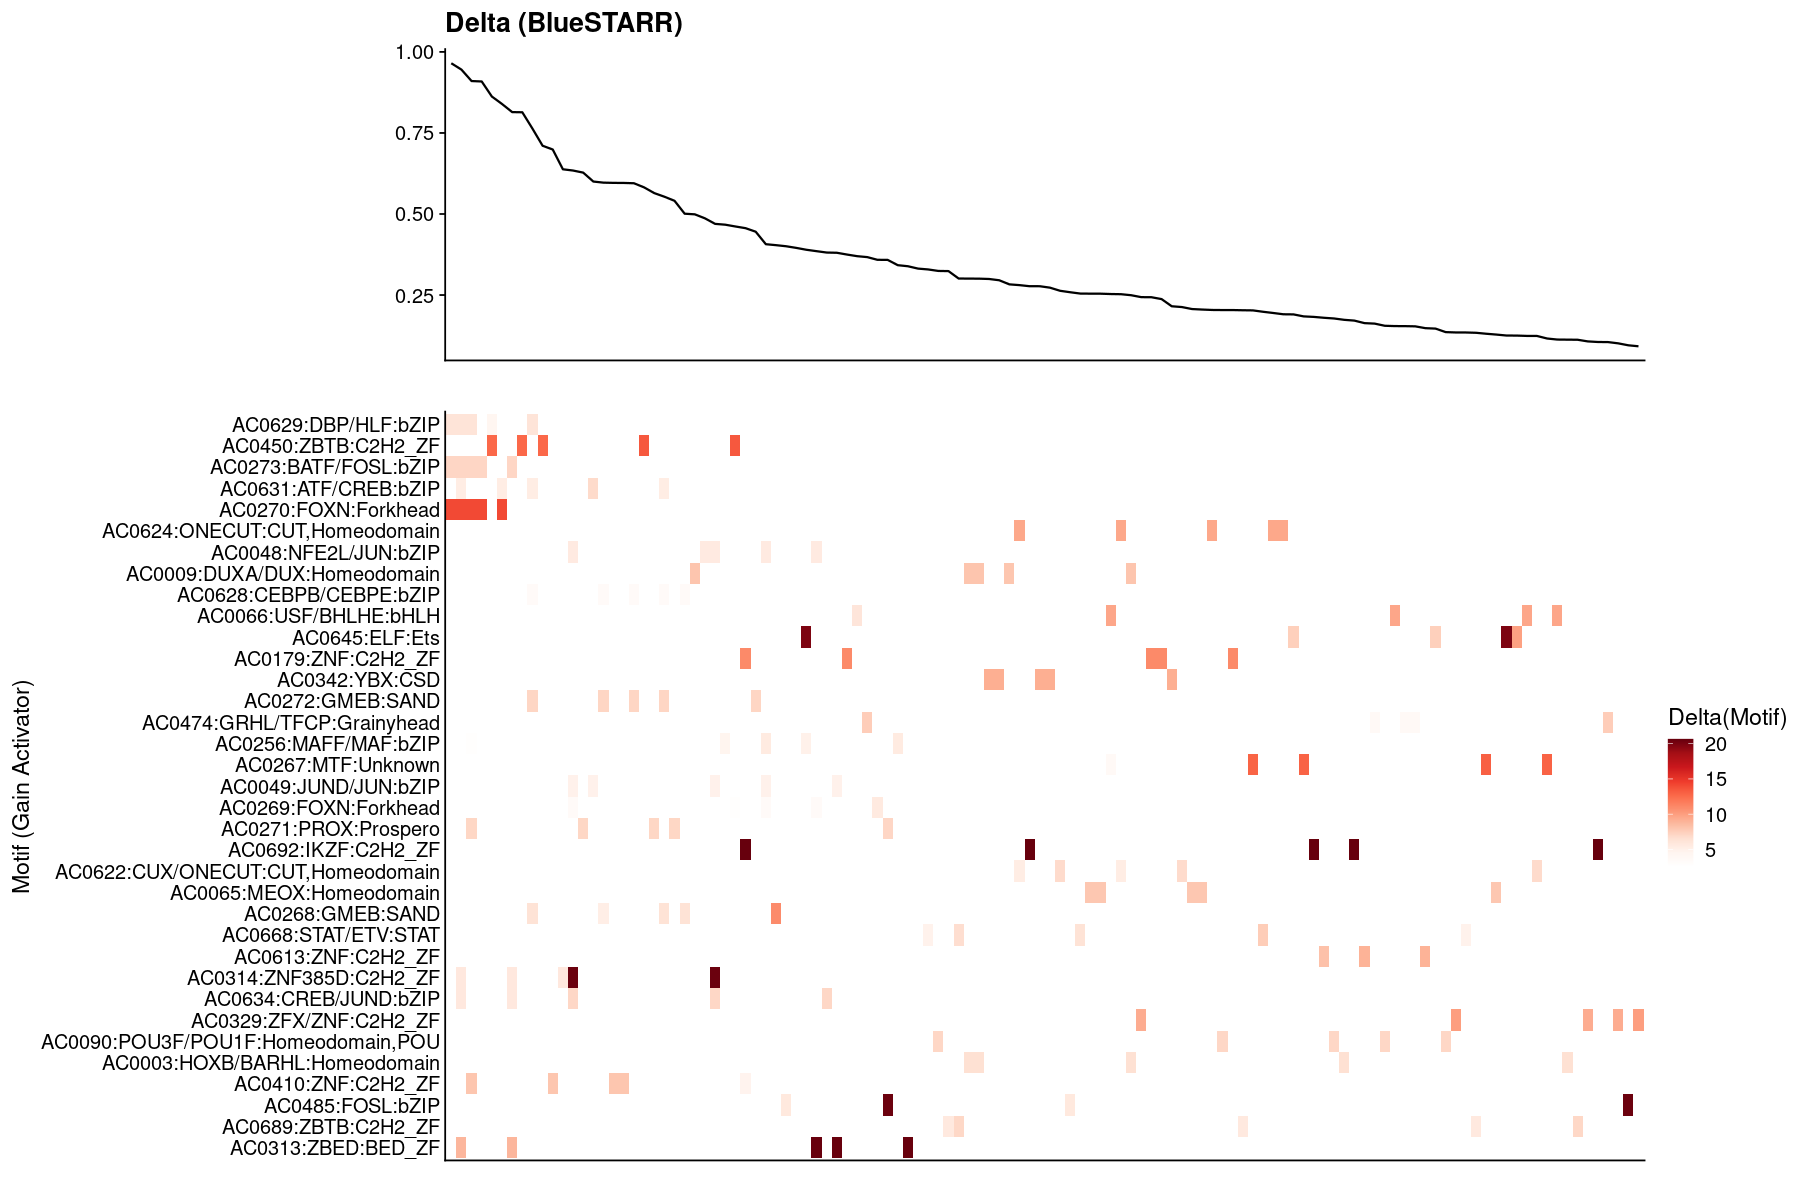

In [101]:
lst = list(
    gpt_Y + labs(x="", y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="", y = "Motif (Gain Activator)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 2),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=15)
print(plt)

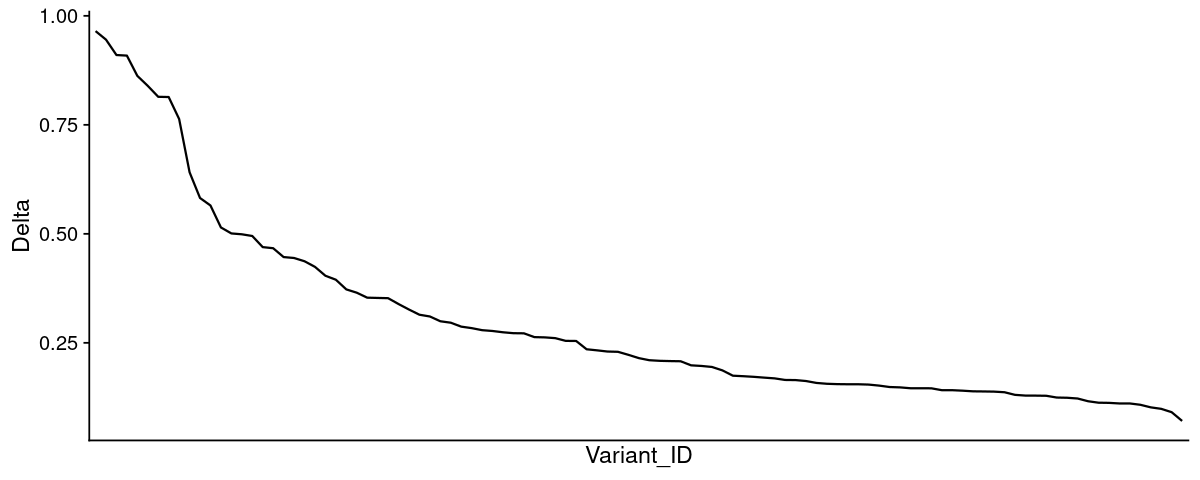

In [92]:
### filter variants
dat = dat_Y
vec = dat_loss_cases$Variant_ID
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec) %>%
    dplyr::arrange(desc(Delta))

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

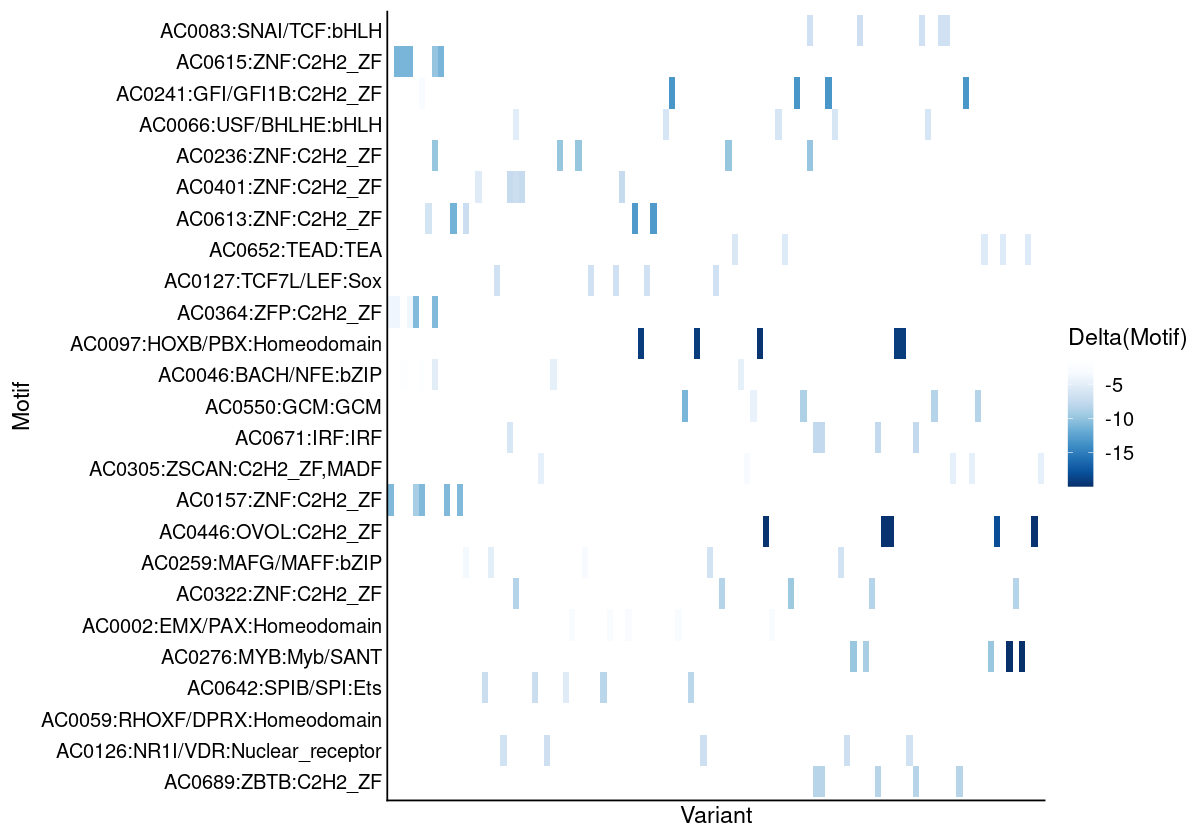

In [93]:
###
vec_txt_color = RColorBrewer::brewer.pal(9, "Blues")
vec_txt_color = rev(vec_txt_color)
vec_txt_color = c(vec_txt_color, "#FFFFFF")

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    #axis.text.y  = element_blank(),
)

###
dat = dat_loss_cases
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    variable   = factor(variable,   levels=rev(vec_txt_motif_loss_sort))
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = variable, fill = rfvalue)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color, name = "Delta(Motif)") +
    labs(x = "Variant", y = "Motif")

gpt_X = gpt
options(repr.plot.height=7, repr.plot.width=10)
print(gpt)

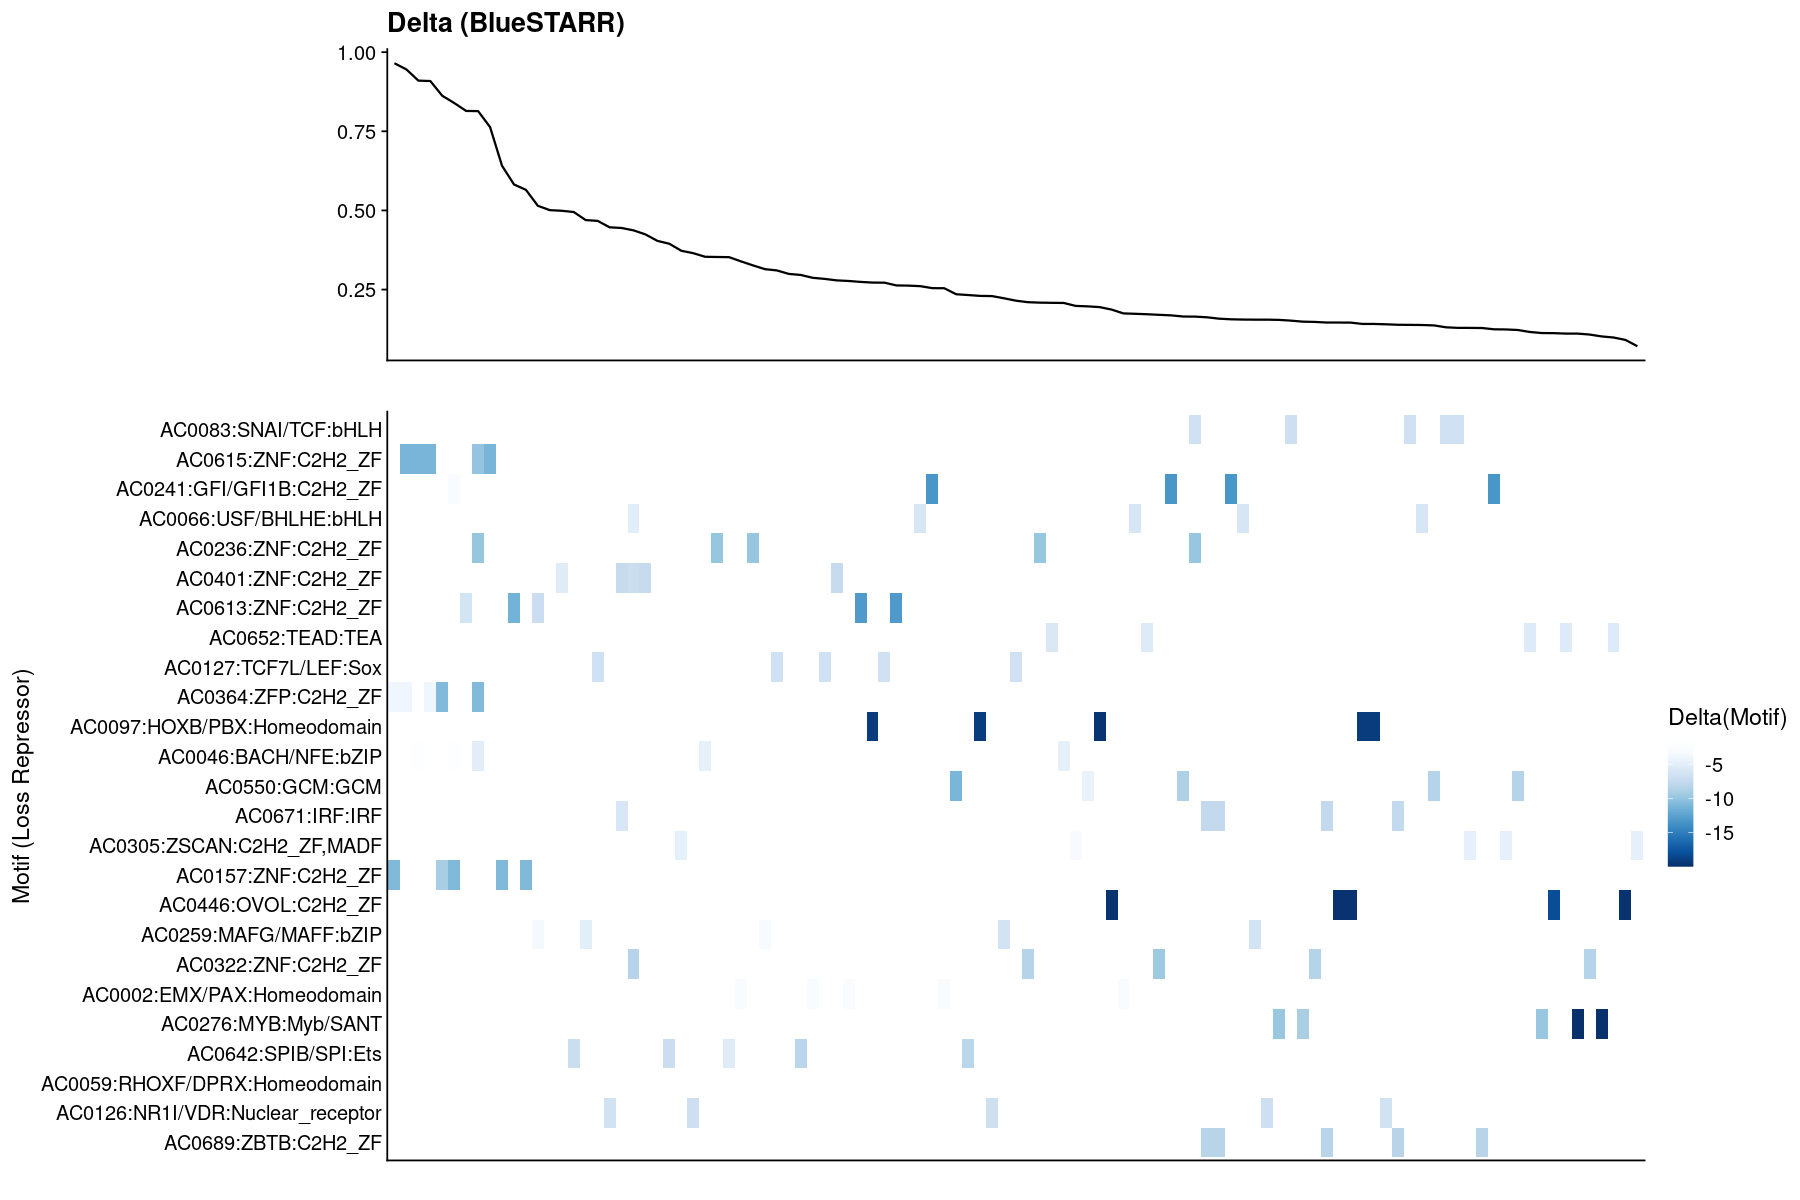

In [95]:
lst = list(
    gpt_Y + labs(x="", y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="", y = "Motif (Loss Repressor)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 2),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=15)
print(plt)

In [ ]:
dat = dat_Y

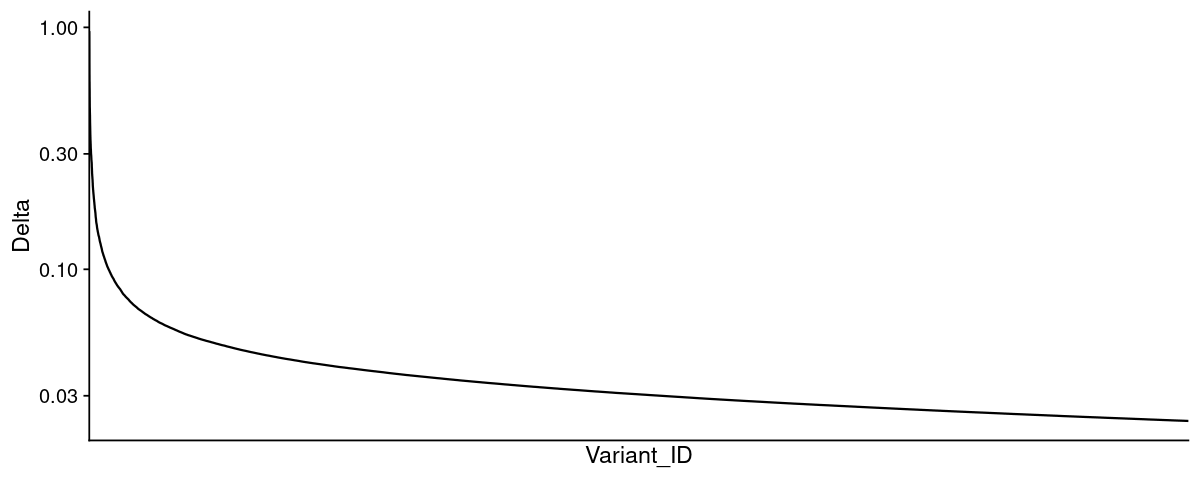

In [72]:
### filter variants
dat = dat_Y

### order variants
dat = dat %>% 
    dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort)) %>%
    dplyr::mutate(Index = as.integer(Variant_ID))
    

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom +
    scale_y_log10()

###
gpt_Y_full = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

In [ ]:
# choose a Delta threshold for “strong GoF”
delta_cut = quantile(dat_pairs$Delta, 0.9, na.rm = TRUE)  # for example

dat_gain_cases = dat_pairs %>%
  dplyr::filter(
    Event     == "gain",
    Variable  %in% vec_gain_motifs,
    value     > 0,          # motif pushes prediction up
    Delta     > delta_cut   # strong increase in STARR
  ) %>%
  dplyr::mutate(
    rank_score = value * Delta * abs(rfvalue)
  ) %>%
  dplyr::group_by(Variable) %>%
  dplyr::slice_max(order_by = rank_score, n = 5, with_ties = FALSE) %>%
  dplyr::ungroup()

dat_loss_cases = dat_pairs %>%
  dplyr::filter(
    Event     == "loss",
    Variable  %in% vec_loss_motifs,
    value     > 0,          # losing motif pushes prediction up
    Delta     > delta_cut
  ) %>%
  dplyr::mutate(
    rank_score = value * Delta * abs(rfvalue)
  ) %>%
  dplyr::group_by(Variable) %>%
  dplyr::slice_max(order_by = rank_score, n = 5, with_ties = FALSE) %>%
  dplyr::ungroup()

In [35]:
dat_loss_repressor

Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AC0083:SNAI/TCF:bHLH,Loss,5085,1.0000000,0.000000000,0.0060579062,0.0060579062,0.4340272,0.3236939,loss_repressor
AC0615:ZNF:C2H2_ZF,Loss,3277,0.8721392,0.127860848,0.0052047435,0.0052374034,-0.6823856,0.3166053,loss_repressor
AC0066:USF/BHLHE:bHLH,Loss,1543,1.0000000,0.000000000,0.0020586443,0.0020586443,-0.4178708,0.3031752,loss_repressor
AC0236:ZNF:C2H2_ZF,Loss,4620,0.5952381,0.404761905,0.0019113409,0.0019912317,-0.8132734,0.2707668,loss_repressor
AC0241:GFI/GFI1B:C2H2_ZF,Loss,1879,0.9941458,0.005854178,0.0049341417,0.0049427116,-0.4966470,0.2182072,loss_repressor
AC0613:ZNF:C2H2_ZF,Loss,1580,0.7639241,0.236075949,0.0012518202,0.0012788847,-0.8778774,0.2671113,loss_repressor
AC0046:BACH/NFE:bZIP,Loss,1653,0.9280097,0.071990321,0.0010755474,0.0011066610,-0.5756002,0.1185891,loss_repressor
AC0550:GCM:GCM,Loss,3157,0.8872347,0.112765283,0.0010828341,0.0010949190,-0.7156772,0.1595096,loss_repressor
AC0157:ZNF:C2H2_ZF,Loss,3438,0.8996510,0.100349040,0.0008413447,0.0008769443,-0.5635358,0.1047991,loss_repressor


In [36]:
dat_gain_activator

Motif,Event_Type,Count,Frac_pos,Frac_neg,Mean_SHAP_Value,Mean_SHAP_Abs,Corr_SHAP_Motif,Corr_SHAP_Delta,Class
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AC0629:DBP/HLF:bZIP,Gain,1761,0.9840999,0.015900057,0.0356994015,0.0357172282,0.06678789,0.6669344,gain_activator
AC0631:ATF/CREB:bZIP,Gain,2435,0.9889117,0.011088296,0.0112181415,0.0114771241,-0.02939926,0.4475002,gain_activator
AC0273:BATF/FOSL:bZIP,Gain,1582,0.6163085,0.383691530,0.0139458153,0.0142623770,0.38723589,0.3353853,gain_activator
AC0450:ZBTB:C2H2_ZF,Gain,861,0.9396051,0.060394890,0.0154773300,0.0154997124,0.35216554,0.4053632,gain_activator
AC0048:NFE2L/JUN:bZIP,Gain,2407,0.9709182,0.029081845,0.0044217274,0.0044386520,-0.40868994,0.3408989,gain_activator
AC0066:USF/BHLHE:bHLH,Gain,2159,0.9939787,0.006021306,0.0030602512,0.0030615079,-0.16062149,0.1752462,gain_activator
AC0256:MAFF/MAF:bZIP,Gain,1920,0.9947917,0.005208333,0.0017430815,0.0017464190,0.44224430,0.1783475,gain_activator
AC0179:ZNF:C2H2_ZF,Gain,2731,0.9681435,0.031856463,0.0024356373,0.0024398199,0.72400769,0.1046333,gain_activator
AC0270:FOXN:Forkhead,Gain,686,0.9489796,0.051020408,0.0063045352,0.0064091707,0.39078386,0.5546345,gain_activator


In [37]:
dat = dat_motif_shap_class
dat = dat %>% 
    dplyr::filter(Class != "weak_or_mixed") %>%
    dplyr::group_by(Variable) %>%
    dplyr::summarise(
        Classes   = paste(unique(paste(Event, Class, sep = ":")), collapse = "; "),
        N_Classes = dplyr::n_distinct(paste(Event, Class))
    ) %>%
    dplyr::filter(N_Classes > 1)

### assign and show
dat_motif_multi_class = dat
print(dim(dat))
fun_display_table(head(dat))

ERROR: [1m[33mError[39m in `dplyr::group_by()`:[22m
[1m[22m[33m![39m Must group by variables found in `.data`.
[31m✖[39m Column `Variable` is not found.


In [48]:
dat_pairs = dat_shap_arrange %>%
  dplyr::mutate(
    Variable = as.character(variable),
    Event    = dplyr::case_when(
      rfvalue > 0 ~ "gain",
      rfvalue < 0 ~ "loss",
      TRUE        ~ "zero"
    )
  ) %>%
  dplyr::filter(Event != "zero")

In [49]:
dat_gain_activator  = dat_motif_shap_class %>% dplyr::filter(Class == "gain_activator")
dat_loss_repressor  = dat_motif_shap_class %>% dplyr::filter(Class == "loss_repressor")

vec_gain_motifs = dat_gain_activator$Variable
vec_loss_motifs = dat_loss_repressor$Variable

In [50]:
# choose a Delta threshold for “strong GoF”
delta_cut = quantile(dat_pairs$Delta, 0.9, na.rm = TRUE)  # for example

dat_gain_cases = dat_pairs %>%
  dplyr::filter(
    Event     == "gain",
    Variable  %in% vec_gain_motifs,
    value     > 0,          # motif pushes prediction up
    Delta     > delta_cut   # strong increase in STARR
  ) %>%
  dplyr::mutate(
    rank_score = value * Delta * abs(rfvalue)
  ) %>%
  dplyr::group_by(Variable) %>%
  dplyr::slice_max(order_by = rank_score, n = 5, with_ties = FALSE) %>%
  dplyr::ungroup()

dat_loss_cases = dat_pairs %>%
  dplyr::filter(
    Event     == "loss",
    Variable  %in% vec_loss_motifs,
    value     > 0,          # losing motif pushes prediction up
    Delta     > delta_cut
  ) %>%
  dplyr::mutate(
    rank_score = value * Delta * abs(rfvalue)
  ) %>%
  dplyr::group_by(Variable) %>%
  dplyr::slice_max(order_by = rank_score, n = 5, with_ties = FALSE) %>%
  dplyr::ungroup()

In [56]:
dat = dat_gain_cases
print(dim(dat))
fun_display_table(head(dat))

[1] 175  11


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID,Delta,Variable,Event,rank_score
162,AC0003:HOXB/BARHL:Homeodomain,0.0201502,6.518857,1.0000000,4.60e-06,chr12:128262078:A:G:T,0.3004969,AC0003:HOXB/BARHL:Homeodomain,gain,0.0394721
161,AC0003:HOXB/BARHL:Homeodomain,0.0190439,6.518857,1.0000000,4.60e-06,chr13:34853836:T:C:A,0.3006794,AC0003:HOXB/BARHL:Homeodomain,gain,0.0373277
255,AC0003:HOXB/BARHL:Homeodomain,0.0173901,6.518857,1.0000000,4.60e-06,chr12:12862701:T:C:A,0.2494206,AC0003:HOXB/BARHL:Homeodomain,gain,0.0282752
541,AC0003:HOXB/BARHL:Homeodomain,0.0182134,6.518857,1.0000000,4.60e-06,chr4:46162401:C:C:A,0.1734972,AC0003:HOXB/BARHL:Homeodomain,gain,0.0205994
1349,AC0003:HOXB/BARHL:Homeodomain,0.0141335,6.518857,1.0000000,4.60e-06,chr11:56426219:T:C:A,0.1123512,AC0003:HOXB/BARHL:Homeodomain,gain,0.0103514
39,AC0009:DUXA/DUX:Homeodomain,0.1113776,8.062706,0.6956934,6.05e-05,chr13:48150414:C:C:A,0.4989459,AC0009:DUXA/DUX:Homeodomain,gain,0.4480559


In [55]:
dat = dat_loss_cases
print(dim(dat))
fun_display_table(head(dat))

[1] 125  11


ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID,Delta,Variable,Event,rank_score
114,AC0002:EMX/PAX:Homeodomain,0.0187869,-2.932622,0.2315366,8.30e-06,chr12:76998343:A:G:T,0.3389557,AC0002:EMX/PAX:Homeodomain,loss,0.0186747
188,AC0002:EMX/PAX:Homeodomain,0.0187869,-2.932623,0.2315365,8.30e-06,chr1:78560641:A:G:T,0.2871244,AC0002:EMX/PAX:Homeodomain,loss,0.0158191
213,AC0002:EMX/PAX:Homeodomain,0.0104811,-2.928214,0.2319401,8.30e-06,chr6:163602790:A:G:T,0.2771397,AC0002:EMX/PAX:Homeodomain,loss,0.0085057
249,AC0002:EMX/PAX:Homeodomain,0.0112910,-2.932622,0.2315366,8.30e-06,chr1:247243731:C:C:A,0.2542257,AC0002:EMX/PAX:Homeodomain,loss,0.0084180
534,AC0002:EMX/PAX:Homeodomain,0.0106528,-2.932623,0.2315365,8.30e-06,chr6:112444101:A:G:T,0.1746015,AC0002:EMX/PAX:Homeodomain,loss,0.0054547
100,AC0046:BACH/NFE:bZIP,0.0360135,-4.873019,0.1273017,9.24e-05,chr9:74921414:A:G:C,0.3535583,AC0046:BACH/NFE:bZIP,loss,0.0620474


In [75]:
### get the variant and delta (BlueSTARR)
dat = dat_XY
dat = dat %>% dplyr::select(Variant_ID, Delta) %>% dplyr::arrange(desc(Delta))
vec = dat$Variant_ID

dat_Y = dat
vec_txt_variant_sort = vec

In [89]:
dat = dat_gain_activator
dat = dat %>% dplyr::arrange(dplyr::desc(Mean_shap_abs))
vec = dat$Variable

vec_txt_motif_gain_sort = vec
head(vec)

[1] "AC0629:DBP/HLF:bZIP"           "AC0450:ZBTB:C2H2_ZF"          
[3] "AC0273:BATF/FOSL:bZIP"         "AC0631:ATF/CREB:bZIP"         
[5] "AC0270:FOXN:Forkhead"          "AC0624:ONECUT:CUT,Homeodomain"

In [90]:
dat = dat_loss_repressor
dat = dat %>% dplyr::arrange(dplyr::desc(Mean_shap_abs))
vec = dat$Variable

vec_txt_motif_loss_sort = vec
head(vec)

[1] "AC0083:SNAI/TCF:bHLH"     "AC0615:ZNF:C2H2_ZF"      
[3] "AC0241:GFI/GFI1B:C2H2_ZF" "AC0066:USF/BHLHE:bHLH"   
[5] "AC0236:ZNF:C2H2_ZF"       "AC0401:ZNF:C2H2_ZF"

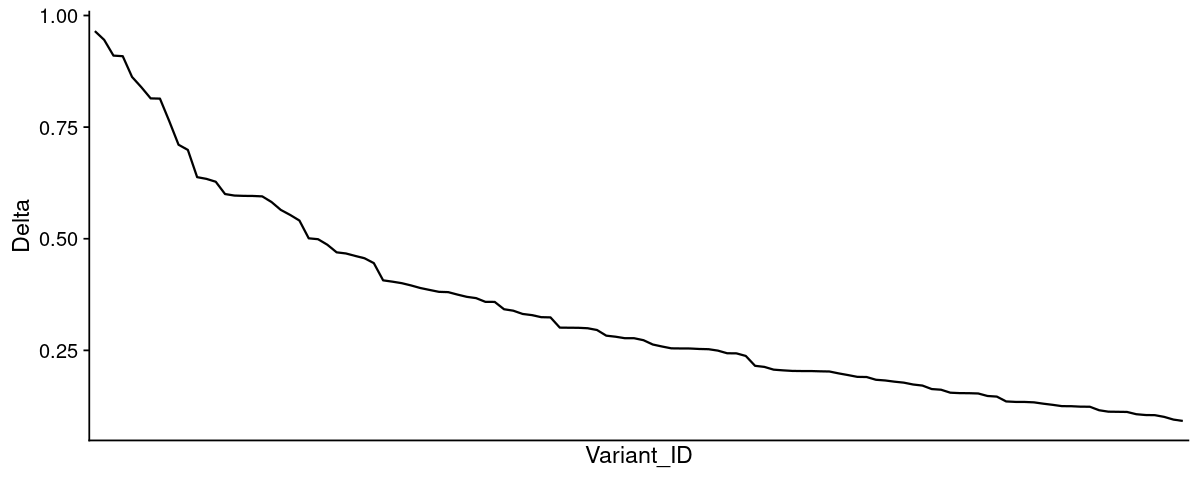

In [99]:
### filter variants
dat = dat_Y
vec = dat_gain_cases$Variant_ID
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec) %>%
    dplyr::arrange(desc(Delta))

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

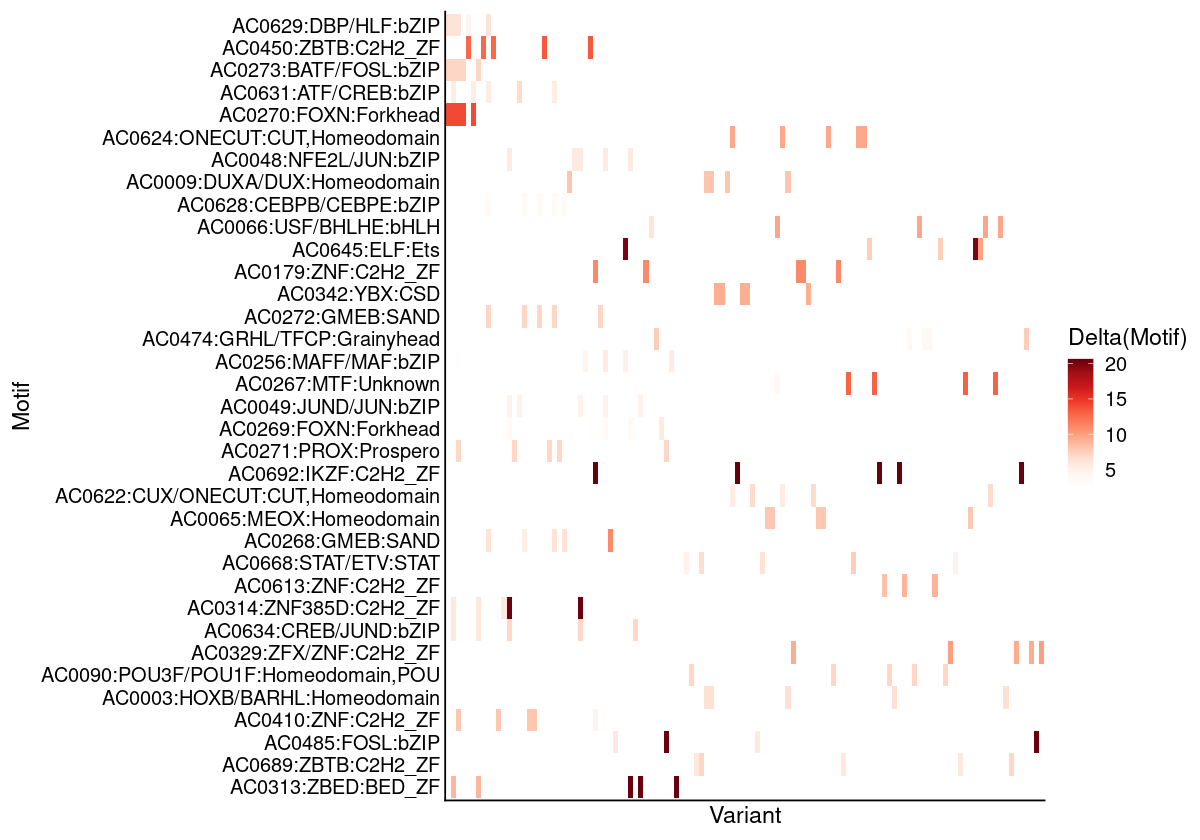

In [100]:
###
vec_txt_color = RColorBrewer::brewer.pal(9, "Reds")
vec_txt_color = c("#FFFFFF", vec_txt_color)

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    #axis.text.y  = element_blank(),
)

###
dat = dat_gain_cases
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    variable   = factor(variable,   levels=rev(vec_txt_motif_sort))
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = variable, fill = rfvalue)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color, name = "Delta(Motif)") +
    labs(x = "Variant", y = "Motif")

gpt_X = gpt
options(repr.plot.height=7, repr.plot.width=10)
print(gpt)

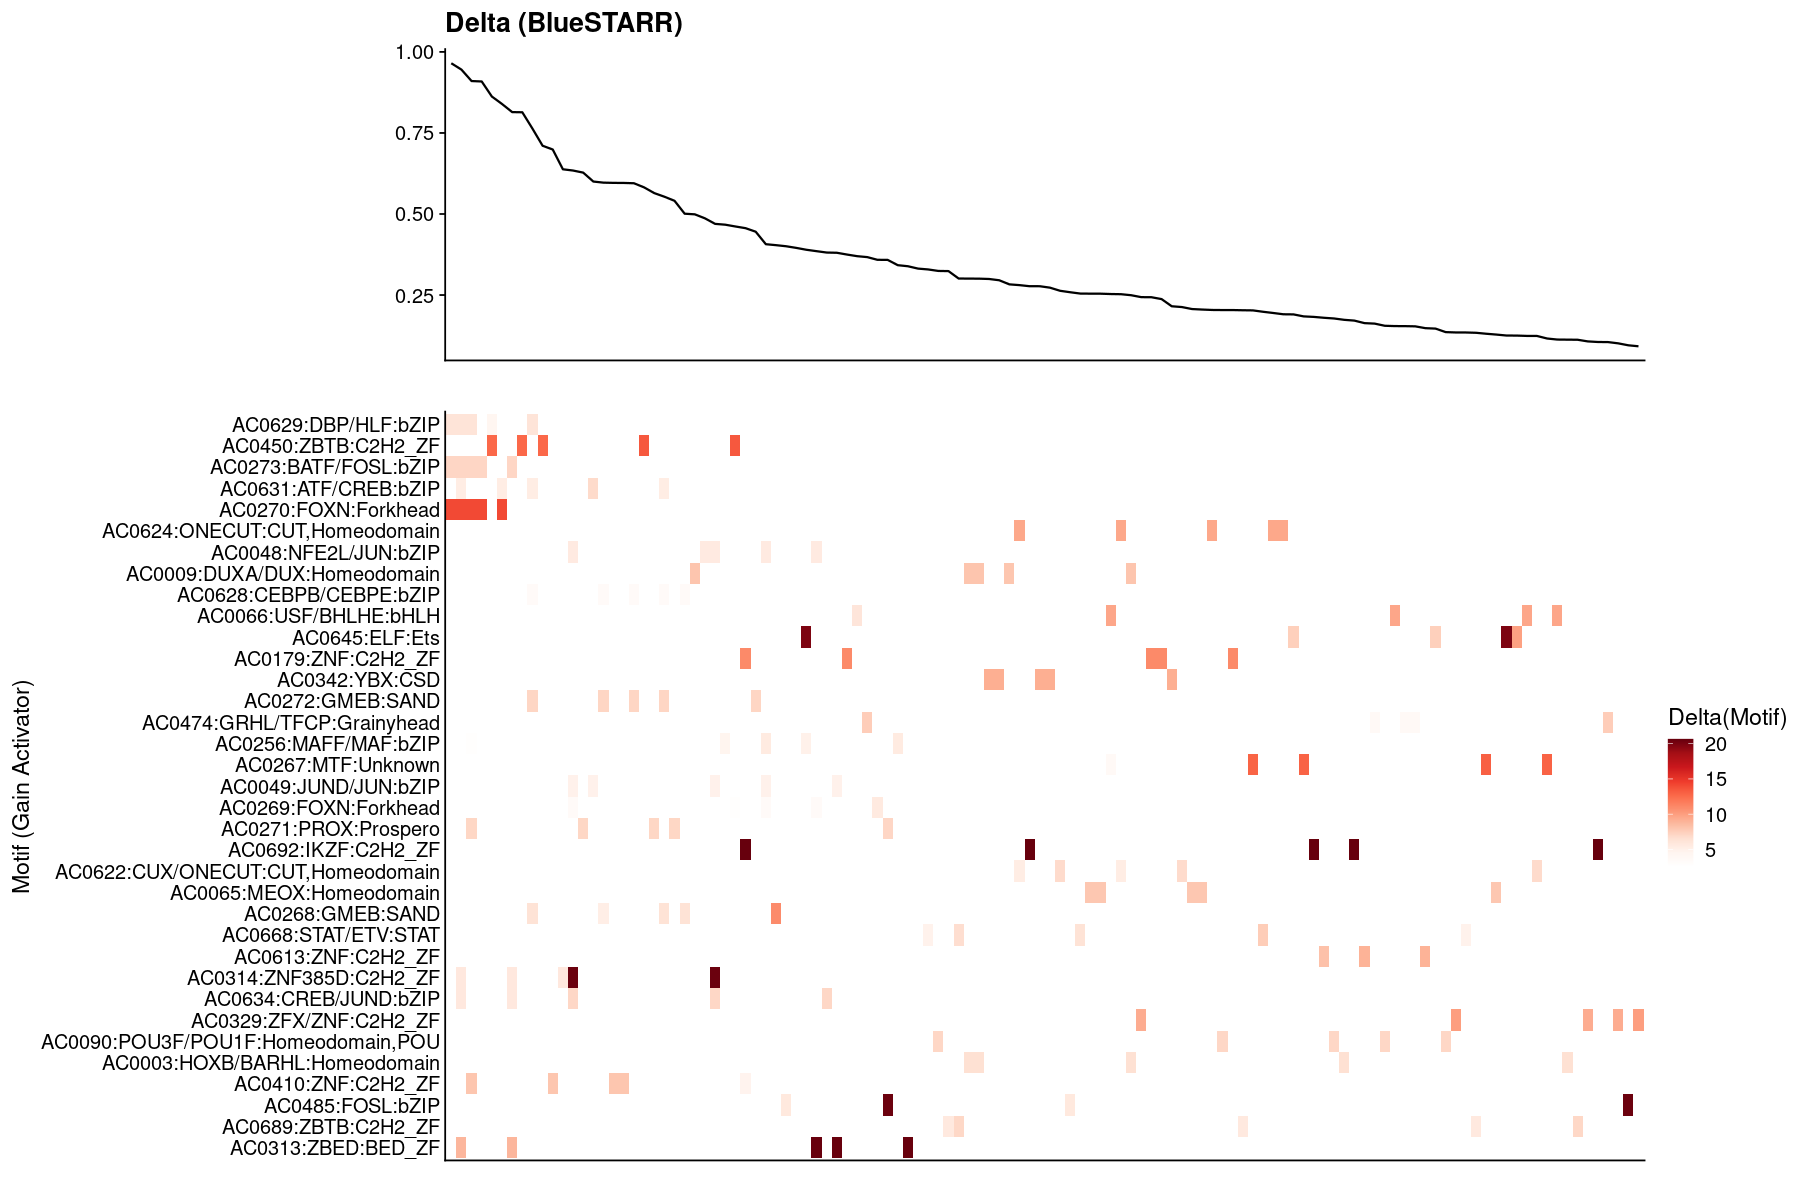

In [101]:
lst = list(
    gpt_Y + labs(x="", y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="", y = "Motif (Gain Activator)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 2),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=15)
print(plt)

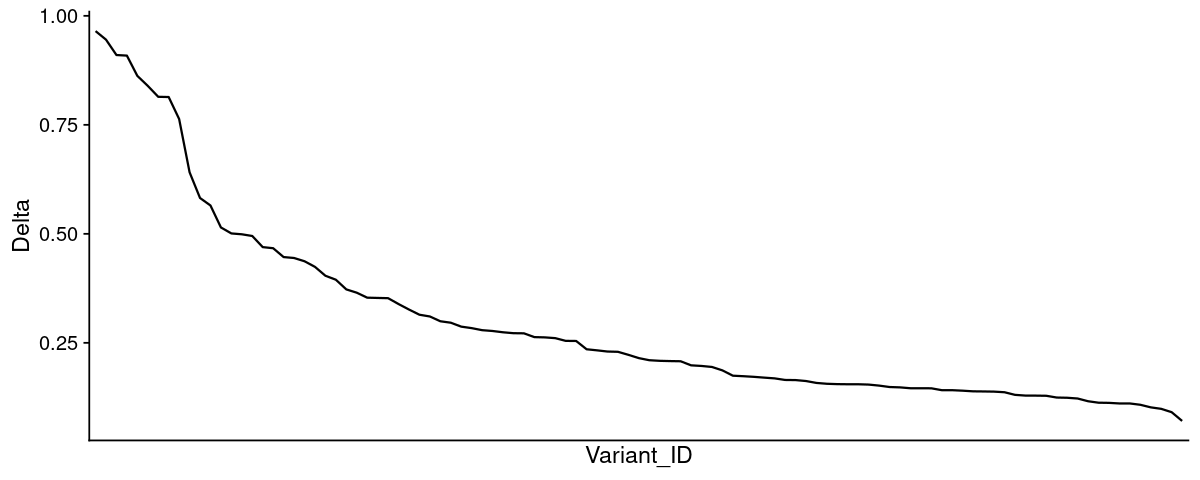

In [92]:
### filter variants
dat = dat_Y
vec = dat_loss_cases$Variant_ID
dat = dat %>% 
    dplyr::filter(Variant_ID %in% vec) %>%
    dplyr::arrange(desc(Delta))

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

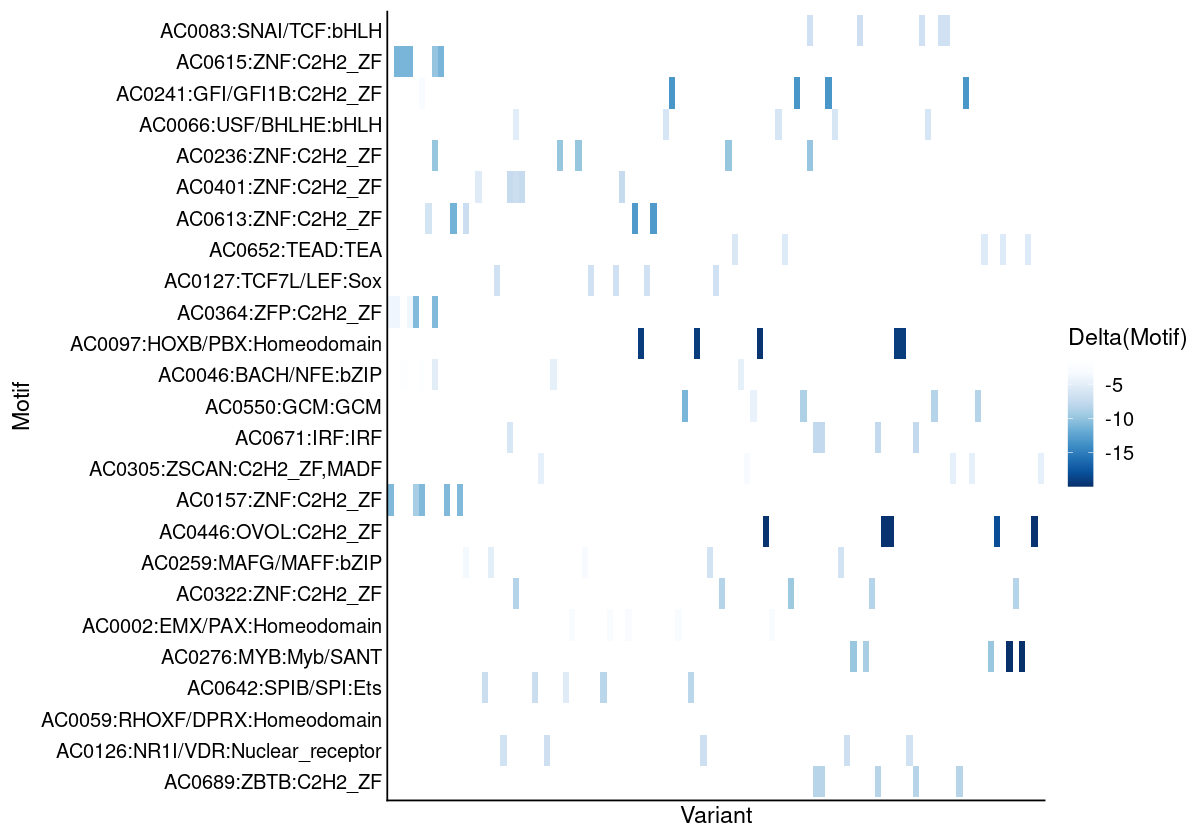

In [93]:
###
vec_txt_color = RColorBrewer::brewer.pal(9, "Blues")
vec_txt_color = rev(vec_txt_color)
vec_txt_color = c(vec_txt_color, "#FFFFFF")

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x  = element_blank(),
    #axis.text.y  = element_blank(),
)

###
dat = dat_loss_cases
dat = dat %>% dplyr::mutate(
    Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort),
    variable   = factor(variable,   levels=rev(vec_txt_motif_loss_sort))
)

###
gpt = ggplot(dat, aes(x=Variant_ID, y = variable, fill = rfvalue)) +
    geom_tile() +
    theme_cowplot() +
    theme_custom +
    scale_fill_gradientn(colors = vec_txt_color, name = "Delta(Motif)") +
    labs(x = "Variant", y = "Motif")

gpt_X = gpt
options(repr.plot.height=7, repr.plot.width=10)
print(gpt)

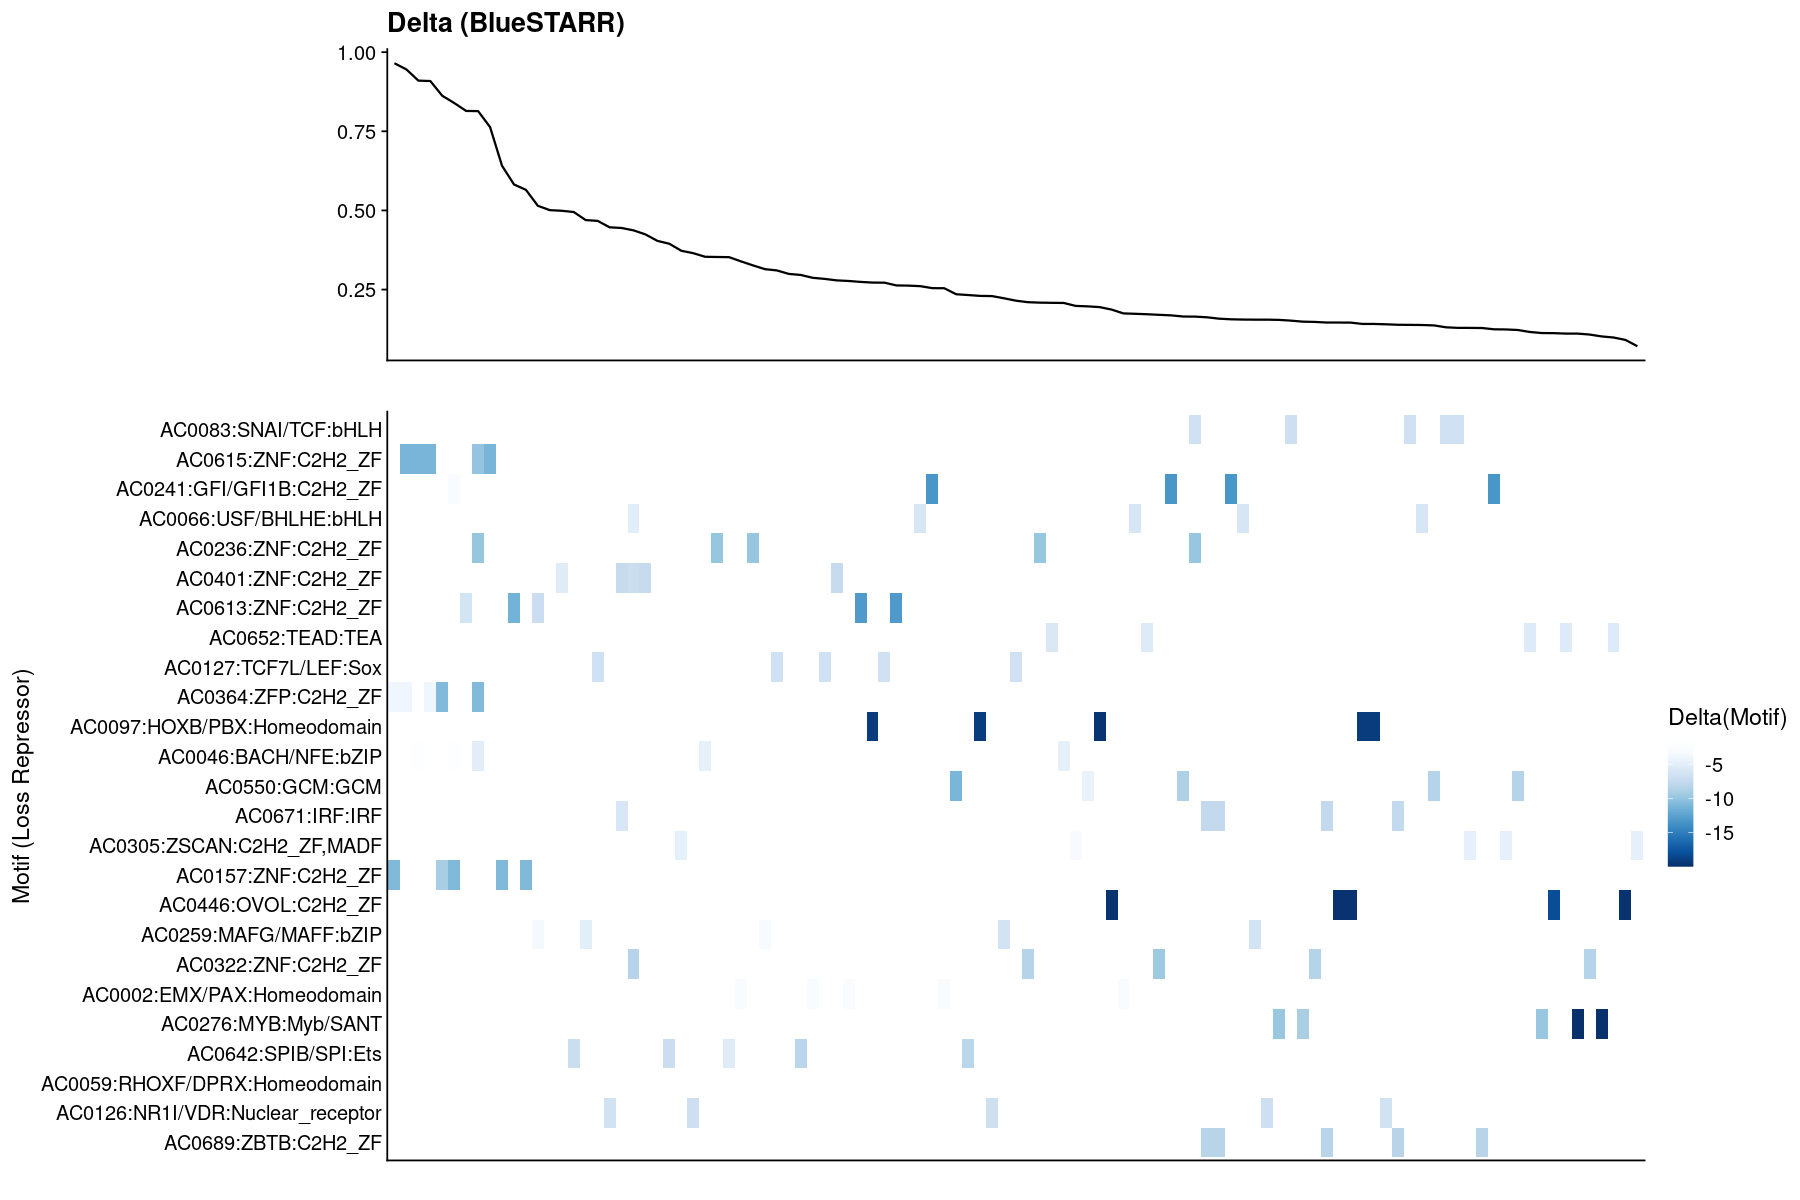

In [95]:
lst = list(
    gpt_Y + labs(x="", y = "", title = "Delta (BlueSTARR)"), 
    gpt_X + labs(x="", y = "Motif (Loss Repressor)")
)
plt = plot_grid(
    plotlist = lst, 
    ncol = 1, 
    rel_heights = c(1, 2),
    align = "v"
)

options(repr.plot.height=10, repr.plot.width=15)
print(plt)


gain_activator loss_activator loss_repressor  weak_or_mixed 
            55              1             37           1006 

## Summarise SHAP per motif

- `mean_shap_nz > 0` -> when this motif is gained, it on average pushes Δ up -> activator-like.
- `corr_shap_nz > 0` -> stronger motif gain -> larger positive contribution.
- `frac_nonzero` tells you how often the motif gain even happens.

In [10]:
fun_cor_safe = function(x, y, min_n = 10) {
    idx = is.finite(x) & is.finite(y)
    x   = x[idx]
    y   = y[idx]
    
    if (length(x) <= min_n){ return(NA_real_) }
    if (sd(x) == 0 || sd(y) == 0){ return(NA_real_) }

    res = cor(x, y, method = "spearman")
    return(res)
}

In [11]:
dat = dat_shap_arrange
dat = dat %>% 
    dplyr::mutate(variable = as.character(variable)) %>%
    dplyr::group_by(variable) %>%
    dplyr::summarise(
        count    = n(),
        
        frac_pos = mean(value > 0),
        frac_neg = mean(value < 0),
        
        mean_shap_val = mean(value),
        mean_shap_abs = mean(abs(value)),
        
        corr_shap_motif = fun_cor_safe(value, rfvalue, min_n = 10),
        corr_shap_delta = fun_cor_safe(value, Delta,   min_n = 10),
        .groups = "drop"
    )

### assign and show
dat_motif_shap_summary = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 583   8


variable,count,frac_pos,frac_neg,mean_shap_val,mean_shap_abs,corr_shap_motif,corr_shap_delta
AC0002:EMX/PAX:Homeodomain,1029,0.6608358,0.3391642,0.0003565,0.0004128,-0.6343635,0.0850463
AC0003:HOXB/BARHL:Homeodomain,610,0.4803279,0.5196721,0.0003978,0.0004002,0.8278552,0.0600467
AC0004:PAX/LHX:Homeodomain,1014,0.5670611,0.4329389,-0.0002145,0.0002226,0.8084118,0.1214250
AC0005:POU6F/NKX:Homeodomain,1060,0.0000000,0.0000000,0.0000000,0.0000000,NA,NA
"AC0006:POU3F/POU1F:Homeodomain,POU",1178,0.3191851,0.6808149,0.0001602,0.0001641,0.5532696,0.0953767
AC0008:GATA:GATA,981,0.9398573,0.0601427,0.0003812,0.0003828,-0.8367522,-0.0138753


In [12]:
dat = dat_shap_arrange
dat = dat %>% dplyr::filter(variable == "AC0005:POU6F/NKX:Homeodomain")
head(dat)

ID,variable,value,rfvalue,stdfvalue,mean_value,Variant_ID,Delta
<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
184,AC0005:POU6F/NKX:Homeodomain,0,6.140269,0.7705336,0,chr11:101381361:G:G:A,0.2902150
378,AC0005:POU6F/NKX:Homeodomain,0,6.140269,0.7705336,0,chr12:48889168:C:C:T,0.2057270
381,AC0005:POU6F/NKX:Homeodomain,0,4.865107,0.7143513,0,chr2:136696768:C:T:A,0.2052685
407,AC0005:POU6F/NKX:Homeodomain,0,4.865107,0.7143513,0,chr13:38890889:A:A:T,0.1991417
468,AC0005:POU6F/NKX:Homeodomain,0,8.366564,0.8686217,0,chr20:23600136:A:G:T,0.1858392
751,AC0005:POU6F/NKX:Homeodomain,0,-4.865107,0.2856487,0,chr7:84522864:T:T:A,0.1452400


In [15]:
### summary of shap summary
dat = dat_motif_shap_summary

### filter out NAs
dat = dat %>% na.omit

### summarize
dat = dat %>% 
    dplyr::summarize(
        across(
            where(is.numeric), 
            list(Min = min, Mean = mean, Median = median, Max = max),
            .names = "{.col}:{.fn}"
        ) 
    )

### arrange to table
dat = dat %>%
    tidyr::pivot_longer(
        cols = everything(),               
        names_to  = c("Variable", ".value"), 
        names_sep = ":"
    )

### show column summary
fun_display_table(dat)

Variable,Min,Mean,Median,Max
count,575.0000000,4006.0654545,3365.5000000,1.859500e+04
frac_pos,0.0183318,0.5670600,0.5669328,9.964884e-01
frac_neg,0.0035116,0.4329400,0.4330672,9.816682e-01
mean_shap_val,-0.0007035,0.0002667,0.0000317,2.725260e-02
mean_shap_abs,0.0000003,0.0003244,0.0000701,2.750160e-02
corr_shap_motif,-0.9352019,0.0390038,0.1100079,9.498997e-01
corr_shap_delta,-0.0936858,0.0433629,0.0323060,6.361650e-01


In [36]:
dat = dat_motif_shap_summary

### filter out NAs
dat = dat %>% na.omit

### get the threshold abs(SHAP) to select important motifs
#vec = dat$mean_shap_abs
#num = quantile(vec, 0.9)
#dat = dat %>% dplyr::filter(mean_shap_abs > num)


### get the activators
tmp = dat %>% 
    dplyr::filter(frac_pos > 0.7) %>%
    dplyr::filter(mean_shap_val	> 0) %>%
    dplyr::filter(corr_shap_delta > 0)
dat_motif_activator = tmp
print(dim(tmp))

### get the repressors
tmp = dat %>% 
    dplyr::filter(frac_neg > 0.7) %>%
    dplyr::filter(mean_shap_val	< 0) %>%
    dplyr::filter(corr_shap_delta < 0)
dat_motif_repressor = tmp
print(dim(tmp))

[1] 110   8
[1] 2 8


In [38]:
dat = dat_motif_shap_summary

### filter out NAs
dat = dat %>% na.omit

### get the repressors
tmp = dat %>% 
    dplyr::filter(frac_neg > 0.7) %>%
    dplyr::filter(mean_shap_val	< 0) %>%
    dplyr::filter(corr_shap_delta < 0)
dat_motif_repressor = tmp
print(dim(tmp))
tmp

[1] 2 8


variable,count,frac_pos,frac_neg,mean_shap_val,mean_shap_abs,corr_shap_motif,corr_shap_delta
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AC0250:ZNF:C2H2_ZF,3771,0.1638823,0.8361177,-3.131824e-05,5.007614e-05,0.7389769,-0.005180689
AC0504:ZNF:C2H2_ZF,12107,0.2343272,0.7656728,-1.718596e-06,2.756384e-06,-0.2950495,-0.003892954


In [37]:
dat_motif_repressor

variable,count,frac_pos,frac_neg,mean_shap_val,mean_shap_abs,corr_shap_motif,corr_shap_delta
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AC0250:ZNF:C2H2_ZF,3771,0.1638823,0.8361177,-3.131824e-05,5.007614e-05,0.7389769,-0.005180689
AC0504:ZNF:C2H2_ZF,12107,0.2343272,0.7656728,-1.718596e-06,2.756384e-06,-0.2950495,-0.003892954


In [35]:
dat_motif_activator

variable,count,frac_pos,frac_neg,mean_shap_val,mean_shap_abs,corr_shap_motif,corr_shap_delta
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AC0009:DUXA/DUX:Homeodomain,1452,0.5668044,0.433195592,0.0021089431,0.0021516277,0.817215183,0.11804536
AC0010:PROP/ALX:Homeodomain,747,0.2182062,0.781793842,0.0001718617,0.0009075068,-0.196037439,0.08451698
AC0021:HOXD/FOXC:Homeodomain,575,0.4956522,0.504347826,0.0005854824,0.0013198169,0.487158768,0.11355322
AC0046:BACH/NFE:bZIP,3775,0.7049007,0.295099338,0.0011548039,0.0011985834,0.246038028,0.07227980
AC0048:NFE2L/JUN:bZIP,3694,0.6580942,0.341905793,0.0028784394,0.0029418877,0.528256714,0.25463619
AC0049:JUND/JUN:bZIP,2455,0.6334012,0.366598778,0.0007196811,0.0010338878,0.782010870,0.12319773
AC0065:MEOX:Homeodomain,1414,0.7751061,0.224893918,0.0009116651,0.0009183788,-0.016682999,0.07306114
AC0066:USF/BHLHE:bHLH,3702,0.9964884,0.003511615,0.0026427797,0.0026435126,0.603703605,0.04852284
AC0083:SNAI/TCF:bHLH,5963,0.8650008,0.134999161,0.0051355124,0.0052096588,-0.111722270,0.32980407


In [ ]:
summ_gain_motif <- dat_xgb_gain_shap %>%
  group_by(variable) %>%
  summarise(
    n         = n(),
    mean_shap = mean(rfvalue),
    median_shap = median(rfvalue),
    sd_shap   = sd(rfvalue),
    frac_pos  = mean(rfvalue > 0),
    frac_neg  = mean(rfvalue < 0),
    .groups   = "drop"
  ) %>%
  mutate(direction_gain = case_when(
    mean_shap > 0  ~ "activator_like_gain",
    mean_shap < 0  ~ "repressor_like_gain",
    TRUE           ~ "neutral_gain"
  ))


In [7]:
summ_gain_motif <- dat_xgb_gain_shap %>%
  group_by(variable) %>%
  summarise(
    n         = n(),
    mean_shap = mean(rfvalue),
    median_shap = median(rfvalue),
    sd_shap   = sd(rfvalue),
    frac_pos  = mean(rfvalue > 0),
    frac_neg  = mean(rfvalue < 0),
    .groups   = "drop"
  ) %>%
  mutate(direction_gain = case_when(
    mean_shap > 0  ~ "activator_like_gain",
    mean_shap < 0  ~ "repressor_like_gain",
    TRUE           ~ "neutral_gain"
  ))


In [8]:
# Quick look at top candidates
summ_gain_motif %>%
  arrange(desc(mean_shap)) %>%
  head(20)   # top activator-like in gain

variable,n,mean_shap,median_shap,sd_shap,frac_pos,frac_neg,direction_gain
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AC0172:ZNF:C2H2_ZF,99102,0.3426665,0,1.502768,0.06340942,0,activator_like_gain
AC0583:ZNF:C2H2_ZF,99102,0.3157249,0,1.477925,0.05433795,0,activator_like_gain
AC0504:ZNF:C2H2_ZF,99102,0.3115721,0,1.277084,0.07058384,0,activator_like_gain
AC0171:ZNF:C2H2_ZF,99102,0.3085688,0,1.455805,0.05882828,0,activator_like_gain
AC0505:ZSCAN:C2H2_ZF,99102,0.3066616,0,1.523107,0.04514541,0,activator_like_gain
AC0572:ZNF:C2H2_ZF,99102,0.2888151,0,1.451487,0.05178503,0,activator_like_gain
AC0502:ZNF:C2H2_ZF,99102,0.2815126,0,1.355678,0.05616436,0,activator_like_gain
AC0140:ZNF:C2H2_ZF,99102,0.2811350,0,1.549567,0.03679038,0,activator_like_gain
AC0620:ZNF:C2H2_ZF,99102,0.2768843,0,1.343058,0.04812214,0,activator_like_gain


In [9]:
summ_gain_motif %>%
  arrange(mean_shap) %>%
  head(20)   # top repressor-like in gain

variable,n,mean_shap,median_shap,sd_shap,frac_pos,frac_neg,direction_gain
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AC0191:ZNF:C2H2_ZF,99102,3.980683e-05,0,0.01253138,1.009061e-05,0,activator_like_gain
AC0443:ZNF:C2H2_ZF,99102,1.761762e-04,0,0.04898990,2.018123e-05,0,activator_like_gain
AC0516:AHR:bHLH,99102,1.778012e-04,0,0.05597267,1.009061e-05,0,activator_like_gain
AC0397:ZNF:C2H2_ZF,99102,1.795160e-04,0,0.05651249,1.009061e-05,0,activator_like_gain
AC0309:ZNF:C2H2_ZF,99102,2.008293e-04,0,0.06322202,1.009061e-05,0,activator_like_gain
AC0437:ZNF:C2H2_ZF,99102,2.011985e-04,0,0.06333825,1.009061e-05,0,activator_like_gain
AC0190:ZNF:C2H2_ZF,99102,3.554192e-04,0,0.07974367,2.018123e-05,0,activator_like_gain
AC0649:HINFP:C2H2_ZF,99102,5.230678e-04,0,0.08359628,5.045307e-05,0,activator_like_gain
AC0441:HMX:Homeodomain,99102,6.032885e-04,0,0.10969688,3.027184e-05,0,activator_like_gain


In [ ]:
# Quick look at top candidates
summ_gain_motif %>%
  arrange(desc(mean_shap)) %>%
  head(20)   # top activator-like in gain

summ_gain_motif %>%
  arrange(mean_shap) %>%
  head(20)   # top repressor-like in gain

## Summarise SHAP per motif (gain model)

- `mean_shap_nz > 0` -> when this motif is gained, it on average pushes Δ up -> activator-like.
- `corr_shap_nz > 0` -> stronger motif gain -> larger positive contribution.
- `frac_nonzero` tells you how often the motif gain even happens.

In [4]:
fun_cor_safe = function(x, y, min_n = 10) {
    x = x[is.finite(x)]
    y = y[is.finite(y)]
    
    if (length(x) <= min_n){ return(NA_real_) }
    if (sd(x) == 0 || sd(y) == 0){ return(NA_real_) }

    res = cor(x, y, use = "complete.obs")
    return(res)
}

In [5]:
dat = dat_xgb_gain_shap
dat = dat %>% 
    dplyr::mutate(variable = as.character(variable)) %>%
    dplyr::group_by(variable) %>%
    dplyr::summarise(
        n            = n(),
        n_nonzero    = sum(rfvalue > 0),
        frac_nonzero = n_nonzero / n,
        mean_shap_nz = ifelse(
            n_nonzero > 0,
            mean(value[rfvalue > 0]),
            NA_real_
        ),
        mean_abs_nz  = ifelse(
            n_nonzero > 0,
            mean(abs(value[rfvalue > 0])),
            NA_real_
        ),
        corr_shap_nz = fun_cor_safe(
            rfvalue[rfvalue > 0], 
            value[rfvalue > 0], 
            min_n = 10
        ),
        .groups = "drop"
    )

### assign and show
dat_motif_gain_summary = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 666   7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0001:DLX/LHX:Homeodomain,99102,92,0.0009283,-0.0006585,0.0009043,0.2694117
AC0002:EMX/PAX:Homeodomain,99102,508,0.0051260,0.0000100,0.0000219,0.0399564
AC0003:HOXB/BARHL:Homeodomain,99102,354,0.0035721,0.0008007,0.0008267,0.4401063
AC0004:PAX/LHX:Homeodomain,99102,588,0.0059333,0.0000138,0.0000181,0.0582161
AC0005:POU6F/NKX:Homeodomain,99102,594,0.0059938,-0.0000031,0.0000031,-0.0807775
"AC0006:POU3F/POU1F:Homeodomain,POU",99102,566,0.0057113,0.0006084,0.0006095,0.3448795


```
Pick a "core" set of candidate activators

Filter to motifs that:

Have enough data (n_nonzero large enough).

Have strong effect (mean_abs_nz in top 10% or similar).

Have positive mean_shap_nz and positive cor_gain_shap.
```

In [6]:
### choose a core set based on effect size
dat = dat_motif_gain_summary
vec = dat$mean_abs_nz
vec = vec[!is.na(vec)]
num = quantile(vec, 0.9)
num_threshold_abs = num
print(num)

### filter based on teh threshold
dat = dat_motif_gain_summary
dat = dat %>%
    dplyr::filter(
        n_nonzero   >= 100,              # enough events
        mean_abs_nz >= num_threshold_abs # top 10% by importance
    )
dat_motif_gain_filter = dat
print(dim(dat))

         90% 
0.0006636449 
[1] 63  7


In [10]:
### within this core, get strongest activator-like motifs
dat = dat_motif_gain_filter
dat = dat %>%
    dplyr::filter(
        mean_shap_nz > 0, # pushes Δ up
        corr_shap_nz > 0  # more gain → larger Δ
    ) %>%
    dplyr::arrange(desc(mean_shap_nz))

dat_motif_activator = dat
print(dim(dat))
fun_display_table(head(dat, 20))

[1] 48  7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0629:DBP/HLF:bZIP,99102,1764,0.0177998,0.0384065,0.0384283,0.0547334
AC0450:ZBTB:C2H2_ZF,99102,863,0.0087082,0.0174850,0.0175198,0.0029946
AC0273:BATF/FOSL:bZIP,99102,1610,0.0162459,0.0155743,0.0158109,0.5484898
AC0270:FOXN:Forkhead,99102,686,0.0069222,0.0102431,0.0115597,0.5646235
"AC0624:ONECUT:CUT,Homeodomain",99102,516,0.0052068,0.0064210,0.0064427,0.3236752
AC0009:DUXA/DUX:Homeodomain,99102,881,0.0088898,0.0047262,0.0048264,0.2382832
AC0179:ZNF:C2H2_ZF,99102,2742,0.0276685,0.0029629,0.0029674,0.2348616
AC0272:GMEB:SAND,99102,1038,0.0104741,0.0028281,0.0028944,0.1301188
AC0342:YBX:CSD,99102,1366,0.0137838,0.0026437,0.0026502,0.3139387
AC0047:ZNF:C2H2_ZF,99102,1340,0.0135214,0.0024843,0.0024869,0.1781278


In [11]:
### within this core, get strongest activator-like motifs
dat = dat_motif_gain_filter
dat = dat %>%
    dplyr::filter(
        mean_shap_nz > quantile(mean_shap_nz, 0.9, na.rm = TRUE),
        corr_shap_nz > 0.3 
    ) %>%
    dplyr::arrange(desc(mean_shap_nz))

dat_motif_activator_strict = dat
print(dim(dat))
fun_display_table(head(dat, 20))

[1] 3 7


variable,n,n_nonzero,frac_nonzero,mean_shap_nz,mean_abs_nz,corr_shap_nz
AC0273:BATF/FOSL:bZIP,99102,1610,0.0162459,0.0155743,0.0158109,0.5484898
AC0270:FOXN:Forkhead,99102,686,0.0069222,0.0102431,0.0115597,0.5646235
"AC0624:ONECUT:CUT,Homeodomain",99102,516,0.0052068,0.0064210,0.0064427,0.3236752


This table is a very natural “Top activator candidates (gain model)” table for Bill / committee:

variable: motif name (you may want to map AC IDs → TF family / JASPAR ID later).

mean_shap_nz: average effect on Δ when motif gain is present.

mean_abs_nz: importance.

frac_nonzero: how prevalent the gain is across variants.

cor_gain_shap: monotonicity of the effect.

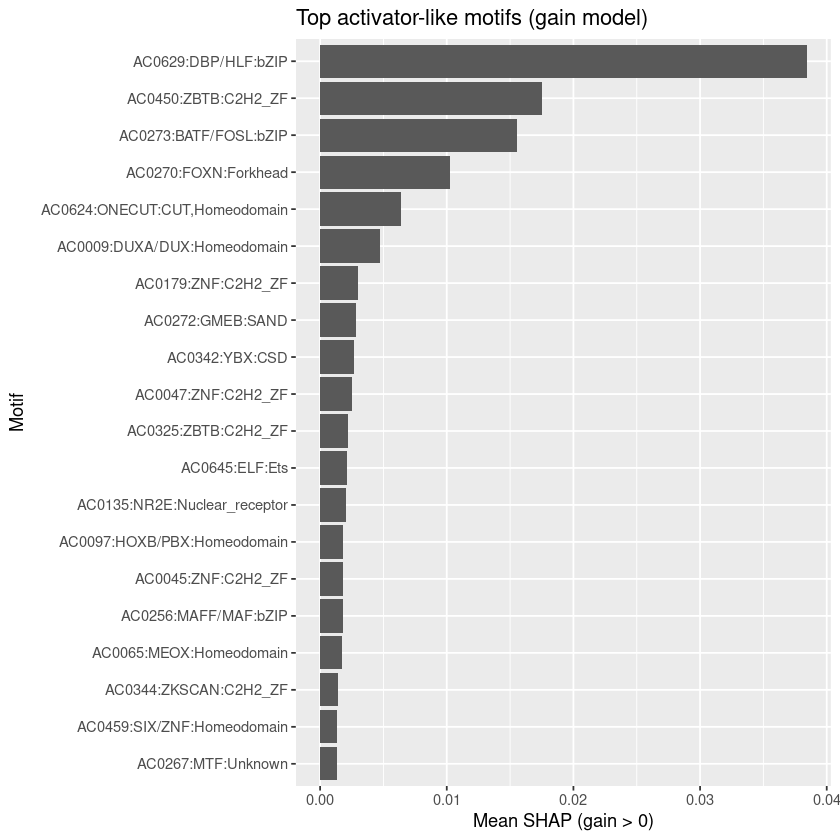

In [12]:
top_act <- dat_motif_activator %>%
  slice_max(order_by = mean_shap_nz, n = 20)

ggplot(top_act,
       aes(x = reorder(variable, mean_shap_nz),
           y = mean_shap_nz)) +
  geom_col() +
  coord_flip() +
  labs(
    x = "Motif",
    y = "Mean SHAP (gain > 0)",
    title = "Top activator-like motifs (gain model)"
  )

In [13]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_motif_activator.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

dat = dat_motif_activator
write_tsv(dat, txt_fpath)

## SHAP dependent plot

Summary of what you are doing conceptually

Gain model:

Features = motif gain strength (0 or >0).

Positive SHAP = “gaining this motif pushes Δ up”.

You summarise SHAP across variants to rank motifs whose gain consistently and strongly increases Δ → activator-like motifs.

Next step (later) will be symmetric:

Use the loss-flip model (features = loss magnitude, SHAP > 0 ⇒ destroying that motif increases Δ) to call repressor-like motifs, using the same kind of summary.

In [16]:
head(dat_xgb_gain_shap)

ID,variable,value,rfvalue,stdfvalue,mean_value
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,AC0629:DBP/HLF:bZIP,0.13007633,6.198104,0.6958730,0.001387135
2,AC0629:DBP/HLF:bZIP,0.13188913,6.198104,0.6958730,0.001387135
3,AC0629:DBP/HLF:bZIP,0.12323806,6.198104,0.6958730,0.001387135
4,AC0629:DBP/HLF:bZIP,0.12072817,6.198104,0.6958730,0.001387135
5,AC0629:DBP/HLF:bZIP,0.24864334,4.409525,0.4950657,0.001387135
6,AC0629:DBP/HLF:bZIP,0.07551295,6.198104,0.6958730,0.001387135


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the SHAPforxgboost package.
  Please report the issue at <https://github.com/liuyanguu/SHAPforxgboost/issues>.”
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.001452”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.038105”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = par

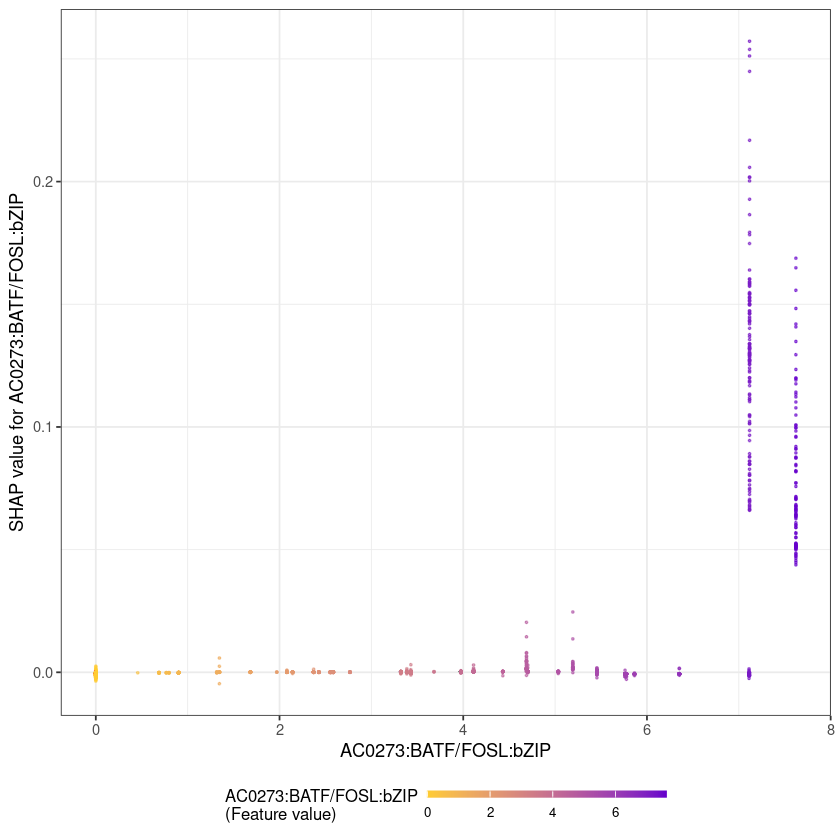

In [24]:
shap.plot.dependence(
    data_long = as.data.table(dat_xgb_gain_shap),
    x = "AC0273:BATF/FOSL:bZIP",
    color_feature = "AC0273:BATF/FOSL:bZIP"
)

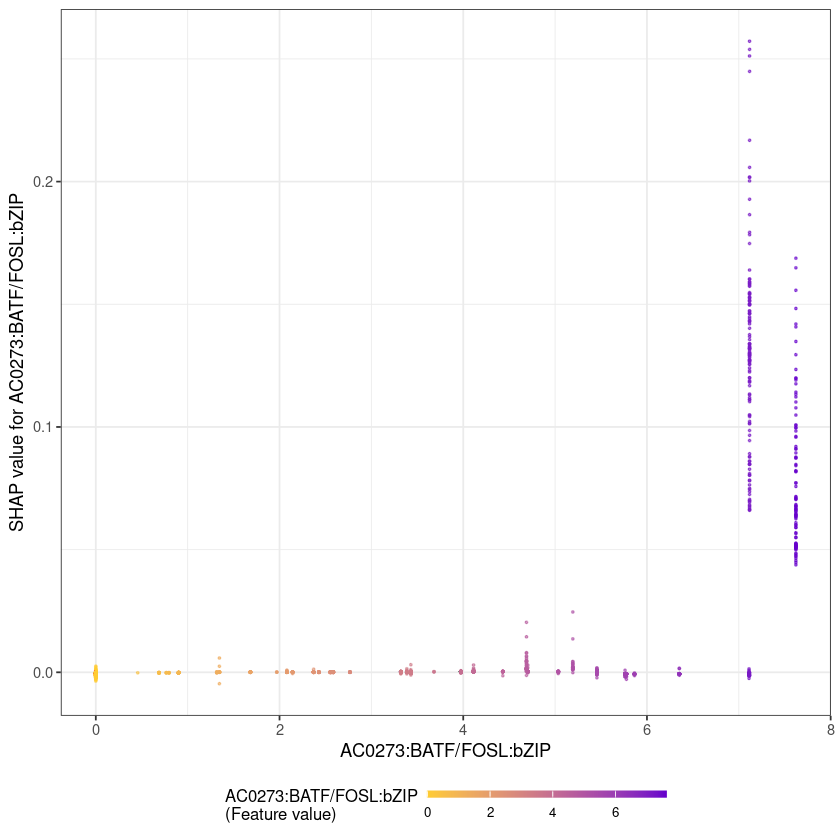

In [25]:
p <- shap.plot.dependence(
  data_long     = as.data.table(dat_xgb_gain_shap),
  x             = "AC0273:BATF/FOSL:bZIP",
  color_feature = "AC0273:BATF/FOSL:bZIP"
)

# Remove smoothing layer if present
p$layers <- p$layers[!vapply(p$layers, function(layer) {
  inherits(layer$geom, "GeomSmooth")
}, logical(1))]

print(p)

In [26]:
class(p)

[1] "ggplot2::ggplot" "ggplot"          "ggplot2::gg"     "S7_object"      
[5] "gg"

In [ ]:
dat = dat_motif_activator
dat = dat %>% 
    tidyr::pivot_wider(
        id_cols   = variable, 
        id_expand = 
        values_from = mean_shap_nz
        